In [1]:
# ============================================================
# STEP 1a - Imports
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    pairwise_distances
)

!pip install prince
import prince           # FAMD
!pip install gower
import gower            # Gower distance
!pip install pyclustering
from pyclustering.cluster.kmedoids import kmedoids

from scipy.stats import (
    chi2_contingency,
    fisher_exact,
    kruskal,
    f_oneway,
    ttest_ind,
    mannwhitneyu
)

from statsmodels.stats.diagnostic import lilliefors

import itertools
import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 32.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=08bd80d72f3b52809eac1b3163462dcbfa4da3077fda133f88904d0c414c27ad
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering


In [2]:
# ============================================================
# STEP 1b - Load files
# ============================================================

from google.colab import files
uploaded = files.upload()

dataset_filename = "dataset_project_eHealth20252026.csv"
codebook_filename = "questionnaire_codebook_eHealth20252026.xlsx"

df = pd.read_csv(dataset_filename)
codebook = pd.read_excel(codebook_filename)

print("Dataset shape:", df.shape)
df.head()

Saving dataset_project_eHealth20252026.csv to dataset_project_eHealth20252026.csv
Saving questionnaire_codebook_eHealth20252026.xlsx to questionnaire_codebook_eHealth20252026.xlsx
Dataset shape: (221, 96)


,age,gender,education,marital,income,audit_1,audit_2,audit_3,audit_4,audit_5,...,swls_1,swls_2,swls_3,swls_4,swls_5,who5_1,who5_2,who5_3,who5_4,who5_5
0,39.0,0,8.0,1.0,14000,4,3,0.0,0,4.0,...,2,0.0,4.0,2.0,0,2.0,3,3.0,3.0,2.0
1,18.0,1,5.0,1.0,25000,4,4,0.0,0,0.0,...,0,4.0,2.0,4.0,4,0.0,0,3.0,2.0,2.0
2,40.0,0,13.0,2.0,56000,0,0,0.0,0,0.0,...,0,2.0,4.0,0.0,2,3.0,2,3.0,2.0,3.0
3,24.0,1,22.0,0.0,35000,1,0,1.0,1,1.0,...,2,2.0,4.0,3.0,4,3.0,2,1.0,2.0,3.0
4,19.0,1,22.0,1.0,42000,2,2,0.0,2,2.0,...,5,7.0,3.0,5.0,7,5.0,5,4.0,3.0,3.0


In [3]:
# ============================================================
# STEP 2 - Build codebook helper table
# ============================================================

# The codebook columns:
#   A = question
#   B = type
#   C = name of column
#   D = codification

# Let's standardize names
cb = codebook.copy()
cb.columns = ["question", "type", "var", "codification"]

# Keep only rows whose column name actually exists in the dataset
cb = cb[cb["var"].isin(df.columns)].reset_index(drop=True)

print("Variables found in codebook:", cb.shape[0])
cb.head()

Variables found in codebook: 96


,question,type,var,codification
0,How old are you?,integer number,age,NaN
1,What is your gender identity?,dropdown,gender,[0] Male [1] Female [2] Non-binary [3] Prefer ...
2,What is your highest level of education comple...,dropdown,education,[5] Elementary school [8] Middle school [13] H...
3,What is your current marital status?,dropdown,marital,[0] Single [1] Married [2] Divorced [3] Widowe...
4,What is your annual household income before ta...,integer number,income,NaN


In [4]:
# ============================================================
# STEP 2a - Detect questionnaire group from 'name of column'
# ============================================================

def detect_group_from_var(v):
    v_low = str(v).lower()
    # 1. De-commenta e correggi questo blocco per catturare età, gender, ecc.
    if v_low in ["age", "gender", "education", "marital", "income"]:
        return "Socioeconomic"

    # Scales by prefix
    if v_low.startswith("audit"): # Usa startswith più generici se possibile
        return "AUDIT"
    if v_low.startswith("dast"):
        return "DAST"
    if v_low.startswith("pgsi"):
        return "PGSI"
    if v_low.startswith("iat"):
        return "IAT"
    # 2. Correzione qui: le colonne sono 'pcl5_1', quindi 'pcl_' non le trovava
    if v_low.startswith("pcl"):
        return "PCL5"
    if v_low.startswith("mspss"):
        return "MSPSS"
    if v_low.startswith("swls"):
        return "SWLS"
    if v_low.startswith("who5"):
        return "WHO-5"
    return "UNKNOWN"

cb["group"] = cb["var"].apply(detect_group_from_var)
cb["group"].value_counts()

,count
group,
IAT,20
PCL5,20
MSPSS,12
DAST,10
AUDIT,10
PGSI,9
Socioeconomic,5
SWLS,5
WHO-5,5


In [5]:
# ============================================================
# STEP 2b - Detect variable type (nominal vs numeric)
# ============================================================

def detect_type(t):
    t = str(t).lower()
    if "dropdown" in t:
        return "nominal"
    if "integer" in t:
        return "numeric"
    if "radio" in t:
        return "numeric"
    # default: treat as numeric/ordinal
    return "numeric"

cb["var_type"] = cb["type"].apply(detect_type)

NOMINAL_VARS = cb[cb["var_type"] == "nominal"]["var"].tolist()
ORDINAL_NUM_VARS = cb[cb["var_type"] == "numeric"]["var"].tolist()

print("Nominal variables:", NOMINAL_VARS)
print("Numeric/ordinal variables:", len(ORDINAL_NUM_VARS))

Nominal variables: ['gender', 'education', 'marital']
Numeric/ordinal variables: 93


In [6]:
# ============================================================
# STEP 2c - Column lists per questionnaire
# ============================================================

def cols(group_name):
    return cb[cb["group"] == group_name]["var"].tolist()

SOCIO_COLS = cols("Socioeconomic")
AUDIT_COLS = cols("AUDIT")
DAST_COLS  = cols("DAST")
PGSI_COLS  = cols("PGSI")
IAT_COLS   = cols("IAT")
PCL5_COLS   = cols("PCL5")
MSPSS_COLS = cols("MSPSS")
SWLS_COLS  = cols("SWLS")
WHO5_COLS  = cols("WHO-5")

ALL_QUESTION_COLS = (
    SOCIO_COLS + AUDIT_COLS + DAST_COLS + IAT_COLS +
    PGSI_COLS + PCL5_COLS + MSPSS_COLS + SWLS_COLS + WHO5_COLS
)

print("Socio:", SOCIO_COLS)
print("AUDIT items:", len(AUDIT_COLS))
print("DAST items :", len(DAST_COLS))
print("PGSI items :", len(PGSI_COLS))
print("IAT items  :", len(IAT_COLS))
print("PCL5 items:", len(PCL5_COLS))
print("MSPSS items:", len(MSPSS_COLS))
print("SWLS items :", len(SWLS_COLS))
print("WHO-5 items:", len(WHO5_COLS))
print("Total questionnaire vars:", len(ALL_QUESTION_COLS))

Socio: ['age', 'gender', 'education', 'marital', 'income']
AUDIT items: 10
DAST items : 10
PGSI items : 9
IAT items  : 20
PCL5 items: 20
MSPSS items: 12
SWLS items : 5
WHO-5 items: 5
Total questionnaire vars: 96


Shape dataset finale: (221, 13)


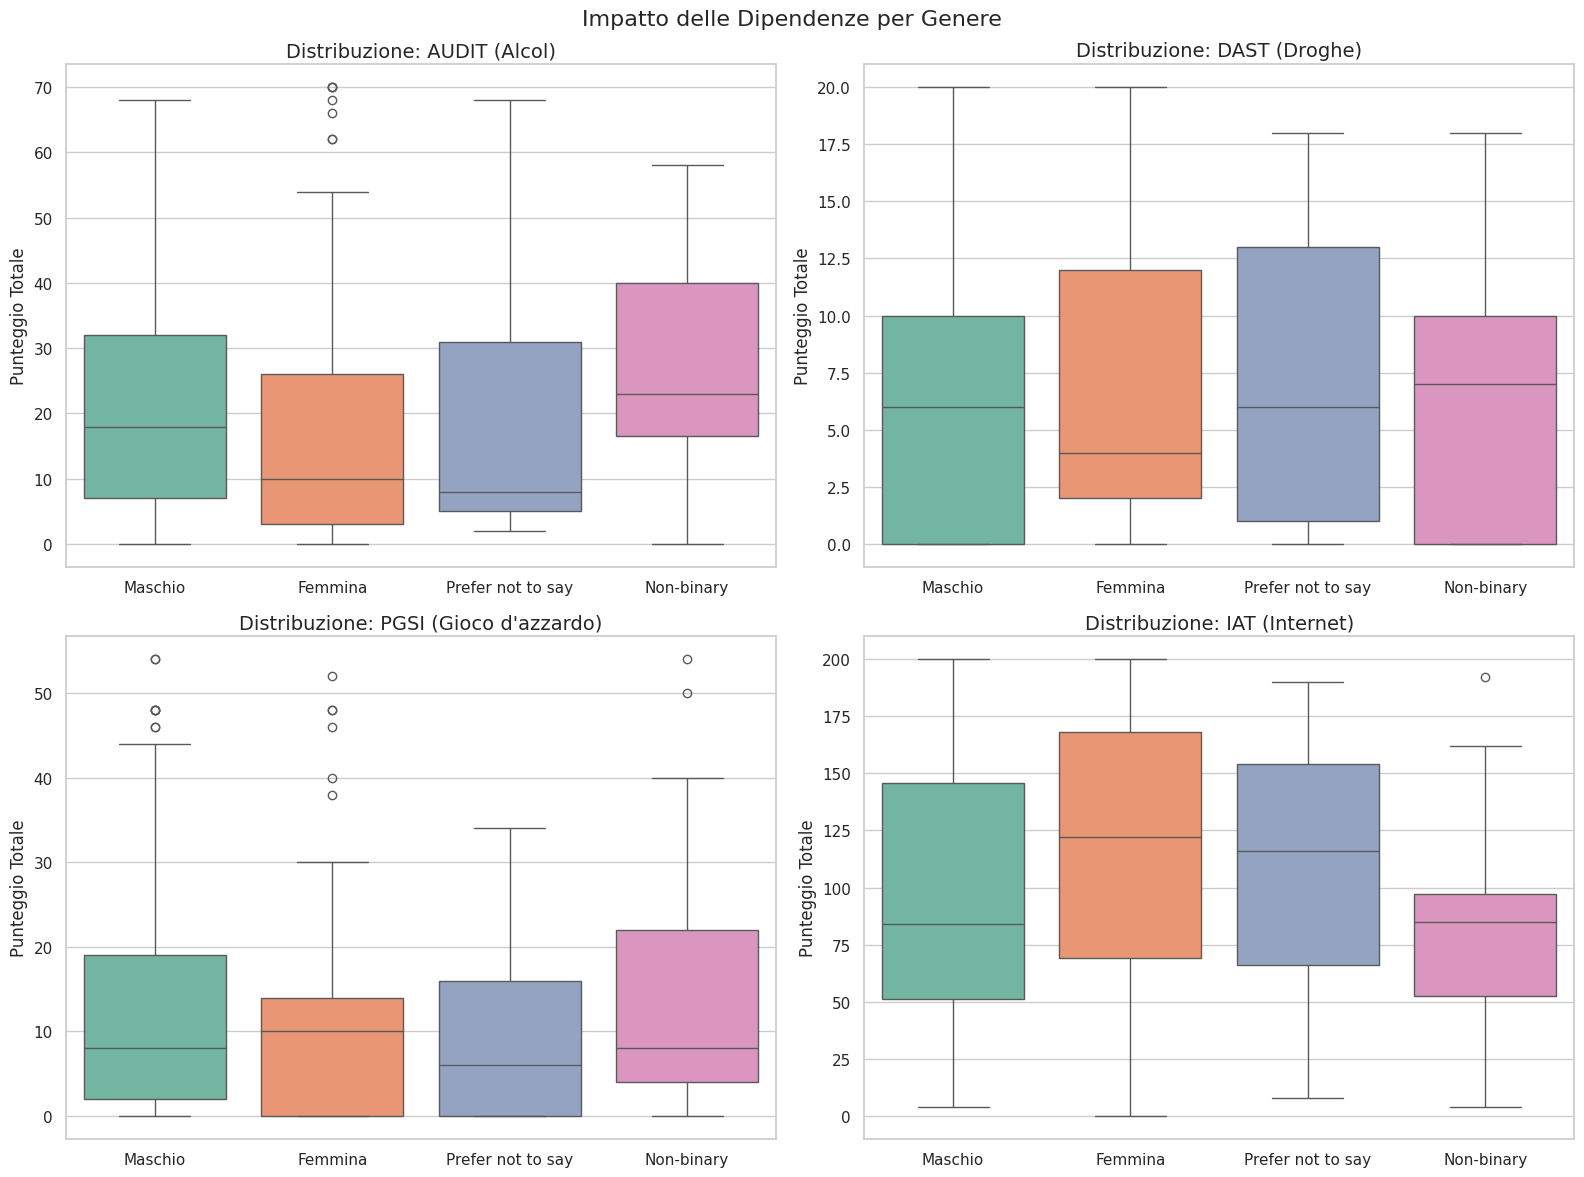

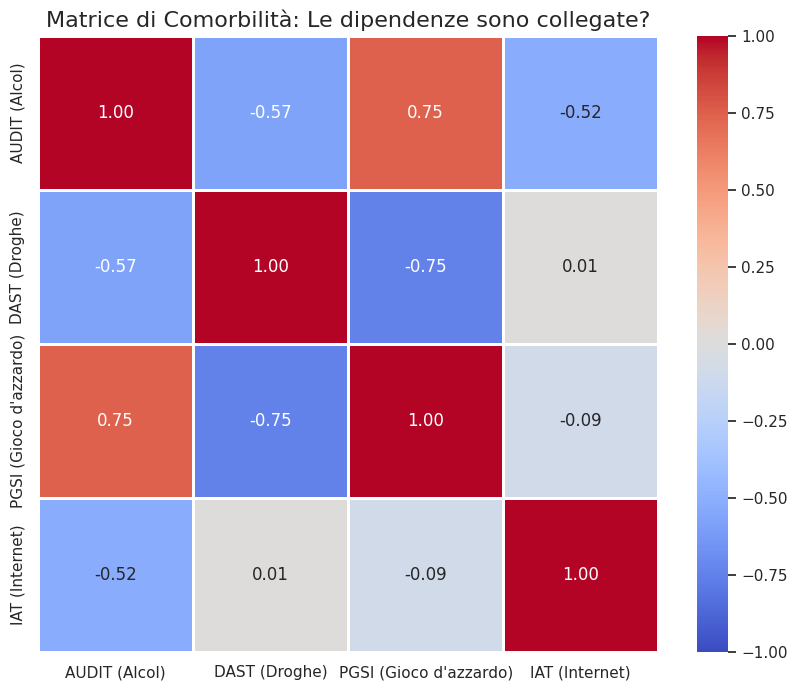

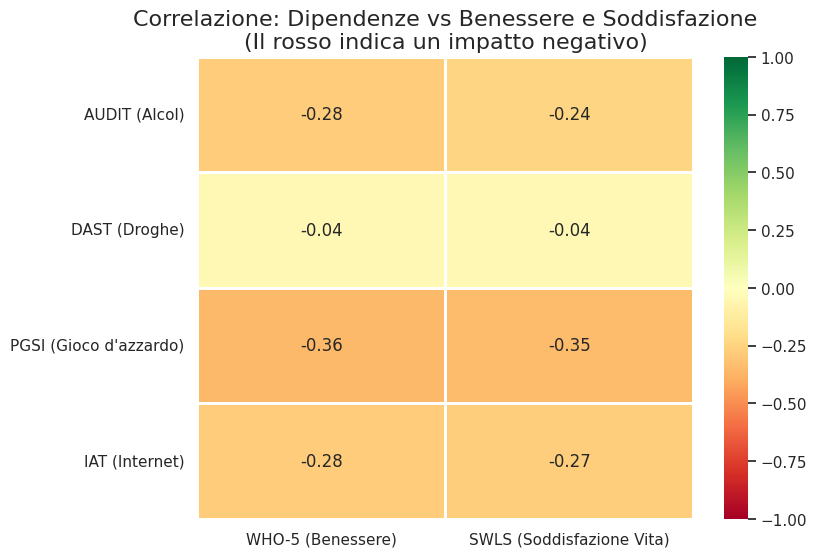

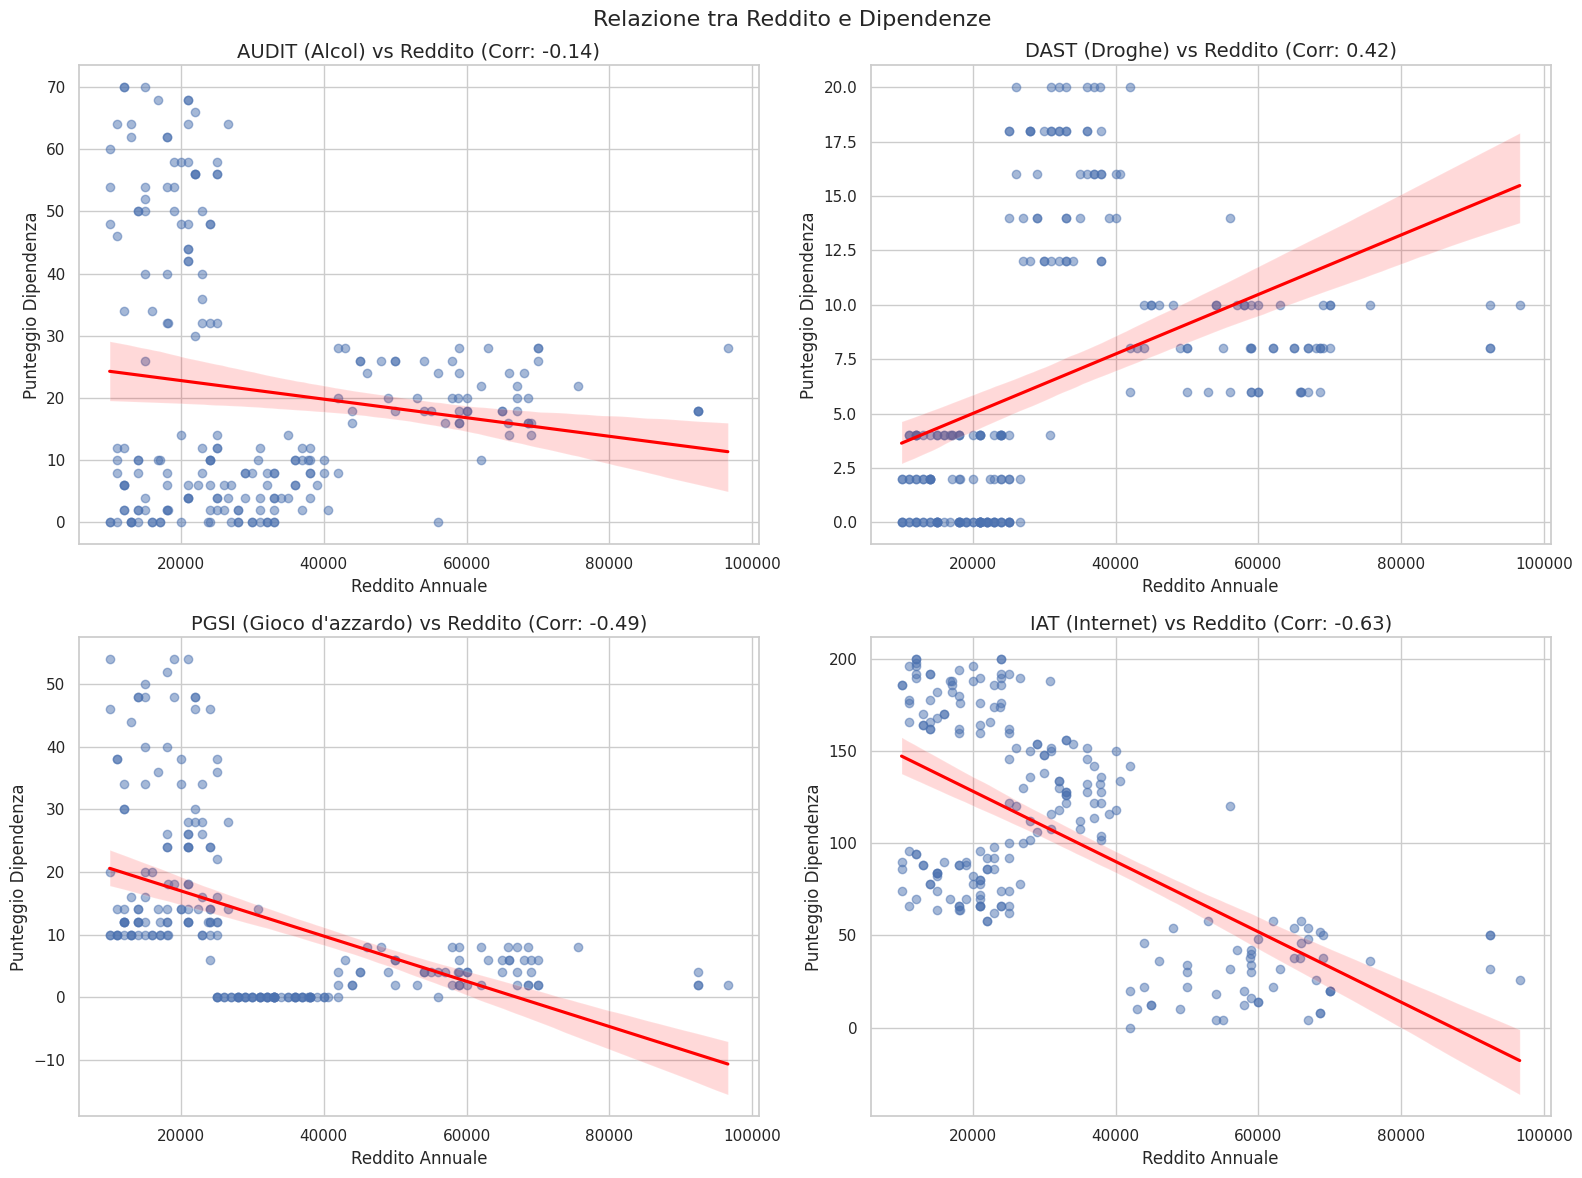

In [7]:
# --- STEP 3: Calcolo dei punteggi aggregati (Feature Engineering) ---

# Assicuriamoci che i dati siano numerici per le somme
# (Opzionale: qui potresti voler gestire i valori mancanti con SimpleImputer prima di sommare)
questionnaire_groups = {
    "audit_score": AUDIT_COLS,
    "dast_score": DAST_COLS,
    "pgsi_score": PGSI_COLS,
    "iat_score": IAT_COLS,
    "pcl5_score": PCL5_COLS,  # Nota: usa PCL5_COLS corretto
    "mspss_score": MSPSS_COLS,
    "swls_score": SWLS_COLS,
    "who5_score": WHO5_COLS
}

# Creiamo le nuove colonne somma
for score_name, cols_list in questionnaire_groups.items():
    if cols_list: # Se la lista non è vuota
        df[score_name] = df[cols_list].sum(axis=1)
    else:
        print(f"Warning: Nessuna colonna trovata per {score_name}")

# --- STEP 4: Creazione del dataset finale per il Clustering ---

# Selezioniamo solo le variabili socio-economiche (singole) e i nuovi score (aggregati)
# SOCIO_COLS ora dovrebbe contenere ['age', 'gender', 'education', 'marital', 'income']
vars_for_clustering = SOCIO_COLS + list(questionnaire_groups.keys())

df_cluster = df[vars_for_clustering].copy()

print("Shape dataset finale:", df_cluster.shape)
df_cluster.head()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. PREPARAZIONE DEI DATI
# ==============================================================================

# Assicurati di avere il dataframe 'df' caricato. Se non lo hai, de-commenta la riga sotto:
# df = pd.read_csv("dataset_project_eHealth20252026.csv")

# Definiamo le colonne per le scale di dipendenza
addiction_scales = {
    "AUDIT (Alcol)": [c for c in df.columns if c.startswith("audit_")],
    "DAST (Droghe)": [c for c in df.columns if c.startswith("dast_")],
    "PGSI (Gioco d'azzardo)": [c for c in df.columns if c.startswith("pgsi_")],
    "IAT (Internet)": [c for c in df.columns if c.startswith("iat_")]
}

# Definiamo le colonne per le scale di impatto (Benessere e Soddisfazione)
impact_scales = {
    "WHO-5 (Benessere)": [c for c in df.columns if c.startswith("who5_")],
    "SWLS (Soddisfazione Vita)": [c for c in df.columns if c.startswith("swls_")]
}

# Creiamo un nuovo dataframe 'scores' per lavorare più puliti
scores = pd.DataFrame()

# Calcoliamo i punteggi totali per ogni scala (somma delle risposte)
for name, cols in addiction_scales.items():
    if cols: # Controllo di sicurezza se le colonne esistono
        scores[name] = df[cols].sum(axis=1)

for name, cols in impact_scales.items():
    if cols:
        scores[name] = df[cols].sum(axis=1)

# Aggiungiamo le variabili socio-demografiche per l'analisi
# Mappiamo il genere per avere etichette leggibili nei grafici
gender_map = {0: 'Maschio', 1: 'Femmina', 2: 'Non-binary', 3: 'Prefer not to say'}
scores['Gender'] = df['gender'].map(gender_map)
scores['Income'] = df['income']

# Impostiamo lo stile dei grafici
sns.set_theme(style="whitegrid")

# ==============================================================================
# ANALISI 1: DISTRIBUZIONE DELLE DIPENDENZE PER GENERE
# ==============================================================================
# Obiettivo: Capire se certe dipendenze sono più prevalenti in un genere specifico.

fig_gender, axes_gender = plt.subplots(2, 2, figsize=(16, 12))
axes_gender = axes_gender.flatten()

for i, col in enumerate(addiction_scales.keys()):
    if col in scores.columns:
        sns.boxplot(data=scores, x="Gender", y=col, ax=axes_gender[i], palette="Set2")
        axes_gender[i].set_title(f'Distribuzione: {col}', fontsize=14)
        axes_gender[i].set_xlabel('')
        axes_gender[i].set_ylabel('Punteggio Totale')

plt.suptitle("Impatto delle Dipendenze per Genere", fontsize=16)
plt.tight_layout()
plt.show()

# ==============================================================================
# ANALISI 2: COMORBILITÀ (Correlazione tra Dipendenze)
# ==============================================================================
# Obiettivo: Vedere se chi ha una dipendenza tende ad averne anche altre.

addiction_cols = list(addiction_scales.keys())
# Calcoliamo la matrice di correlazione solo tra le scale di dipendenza
corr_matrix = scores[addiction_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=1, linecolor='white')
plt.title("Matrice di Comorbilità: Le dipendenze sono collegate?", fontsize=16)
plt.show()

# ==============================================================================
# ANALISI 3: IMPATTO SU BENESSERE E QUALITÀ DELLA VITA
# ==============================================================================
# Obiettivo: Misurare quanto le dipendenze abbassano il benessere (WHO-5) e la soddisfazione (SWLS).

# Correliamo le dipendenze (righe) con le scale di impatto (colonne)
impact_cols = list(impact_scales.keys())
impact_corr = scores[addiction_cols + impact_cols].corr().loc[addiction_cols, impact_cols]

plt.figure(figsize=(8, 6))
sns.heatmap(impact_corr, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-1, vmax=1,
            linewidths=1, linecolor='white')
plt.title("Correlazione: Dipendenze vs Benessere e Soddisfazione\n(Il rosso indica un impatto negativo)", fontsize=16)
plt.show()

# ==============================================================================
# ANALISI 4: IMPATTO SOCIO-ECONOMICO (Relazione col Reddito)
# ==============================================================================
# Obiettivo: Vedere se il reddito è un fattore di rischio o protezione.

fig_income, axes_income = plt.subplots(2, 2, figsize=(16, 12))
axes_income = axes_income.flatten()

for i, col in enumerate(addiction_scales.keys()):
    if col in scores.columns:
        # Scatterplot con linea di regressione
        sns.regplot(data=scores, x="Income", y=col, ax=axes_income[i],
                    scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

        # Calcoliamo la correlazione specifica per mostrarla nel titolo
        corr_val = scores['Income'].corr(scores[col])
        axes_income[i].set_title(f'{col} vs Reddito (Corr: {corr_val:.2f})', fontsize=14)
        axes_income[i].set_xlabel('Reddito Annuale')
        axes_income[i].set_ylabel('Punteggio Dipendenza')

plt.suptitle("Relazione tra Reddito e Dipendenze", fontsize=16)
plt.tight_layout()
plt.show()

✅ Dataset caricato con successo.

--- Calcolo dei Punteggi Totali ---
Creato 'audit_total_score' sommando 10 item.
Creato 'dast_total_score' sommando 10 item.
Creato 'pgsi_total_score' sommando 9 item.
Creato 'iat_total_score' sommando 20 item.
Creato 'pcl5_total_score' sommando 20 item.
Creato 'mspss_total_score' sommando 12 item.
Creato 'swls_total_score' sommando 5 item.
Creato 'who5_total_score' sommando 5 item.

 REPORT EDA (DATI AGGREGATI)

1. Dimensione del Dataset: (221, 13)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                220 non-null    float64
 1   gender             221 non-null    int64  
 2   education          220 non-null    float64
 3   marital            220 non-null    float64
 4   income             221 non-null    int64  
 5   audit_total_score  221 non-null    float64
 6   dast_total_

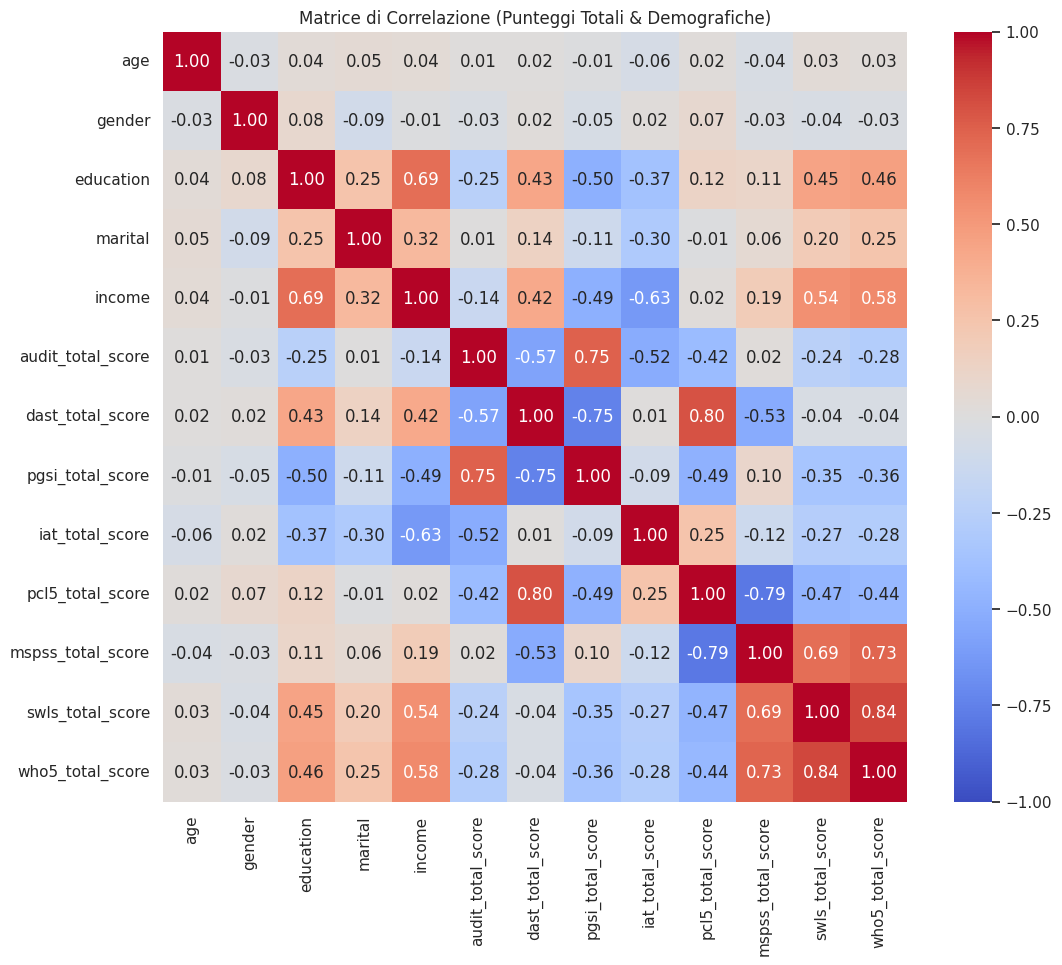

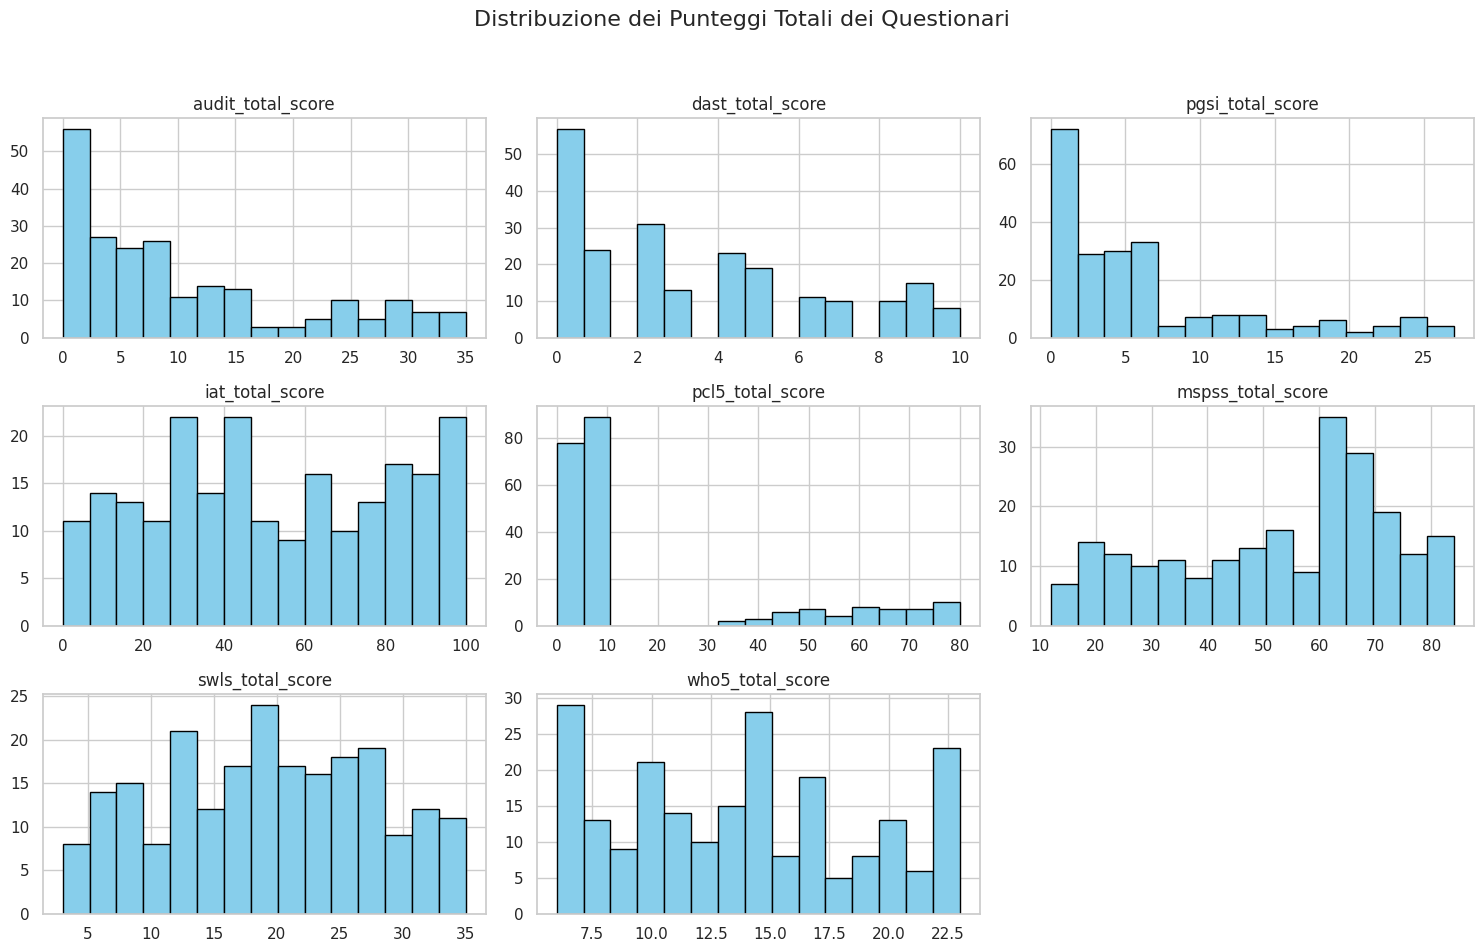

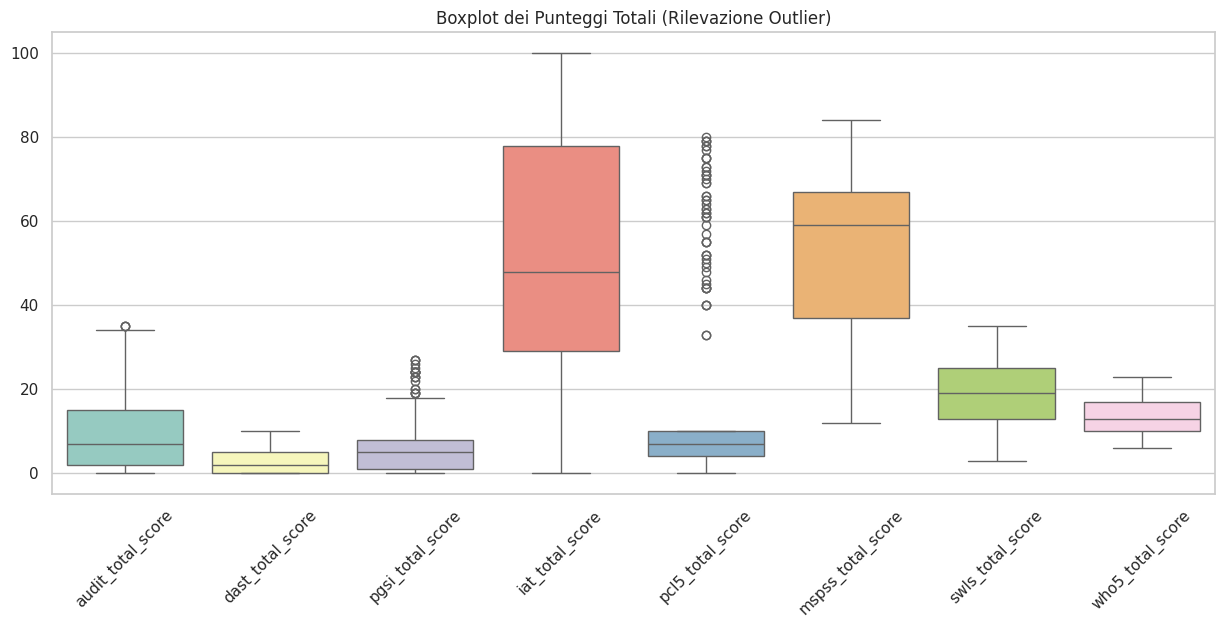

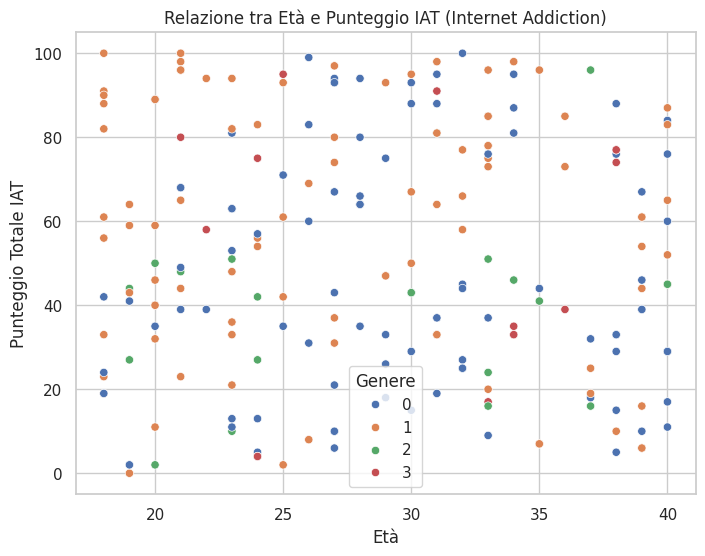

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. CARICAMENTO DATI E AGGREGAZIONE SCORE
# ==========================================

# Carica il dataset
try:
    df = pd.read_csv("dataset_project_eHealth20252026.csv")
    print("✅ Dataset caricato con successo.")
except FileNotFoundError:
    print("❌ Errore: File 'dataset_project_eHealth20252026.csv' non trovato. Caricalo nell'ambiente.")

# Definisci i prefissi dei questionari e le colonne demografiche
questionnaire_prefixes = ['audit', 'dast', 'pgsi', 'iat', 'pcl5', 'mspss', 'swls', 'who5']
demographic_cols = ['age', 'gender', 'education', 'marital', 'income']

# Crea un nuovo DataFrame per i punteggi aggregati
# Manteniamo le colonne demografiche e aggiungiamo le somme
df_agg = df[demographic_cols].copy()

print("\n--- Calcolo dei Punteggi Totali ---")
for prefix in questionnaire_prefixes:
    # Trova tutte le colonne che iniziano con il prefisso (es. audit_1, audit_2...)
    cols = [c for c in df.columns if c.startswith(prefix + '_')]

    if cols:
        # Calcola la somma per riga
        score_col_name = f'{prefix}_total_score'
        df_agg[score_col_name] = df[cols].sum(axis=1)
        print(f"Creato '{score_col_name}' sommando {len(cols)} item.")

# ==========================================
# 2. ANALISI ESPLORATIVA (EDA)
# ==========================================

print("\n" + "="*30)
print(" REPORT EDA (DATI AGGREGATI)")
print("="*30)

# 1. Struttura del Dataset
print(f"\n1. Dimensione del Dataset: {df_agg.shape}")
print("\nInfo:")
df_agg.info()

# 2. Statistiche Descrittive
print("\n2. Statistiche Descrittive:")
display(df_agg.describe()) if 'display' in locals() else print(df_agg.describe())

# 3. Valori Mancanti
print("\n3. Valori Mancanti per Colonna:")
print(df_agg.isnull().sum())

# ==========================================
# 3. VISUALIZZAZIONI
# ==========================================
print("\n4. Generazione Grafici...")

# Imposta lo stile di Seaborn
sns.set_theme(style="whitegrid")

# A. Heatmap delle Correlazioni
plt.figure(figsize=(12, 10))
numeric_df = df_agg.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matrice di Correlazione (Punteggi Totali & Demografiche)")
plt.show()

# B. Distribuzione dei Punteggi (Istogrammi)
score_cols = [c for c in df_agg.columns if '_total_score' in c]
if score_cols:
    df_agg[score_cols].hist(figsize=(15, 10), bins=15, color='skyblue', edgecolor='black')
    plt.suptitle("Distribuzione dei Punteggi Totali dei Questionari", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Aggiusta per il titolo
    plt.show()

# C. Boxplots (per identificare outlier)
if score_cols:
    plt.figure(figsize=(15, 6))
    sns.boxplot(data=df_agg[score_cols], palette="Set3")
    plt.xticks(rotation=45)
    plt.title("Boxplot dei Punteggi Totali (Rilevazione Outlier)")
    plt.show()

# D. Scatter Plot Esemplificativo (Età vs Dipendenza Internet)
# Utile per vedere relazioni tra variabili specifiche
if 'age' in df_agg.columns and 'iat_total_score' in df_agg.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='age', y='iat_total_score', data=df_agg, hue='gender', palette='deep')
    plt.title("Relazione tra Età e Punteggio IAT (Internet Addiction)")
    plt.xlabel("Età")
    plt.ylabel("Punteggio Totale IAT")
    plt.legend(title='Genere')
    plt.show()

In [9]:
import pandas as pd
import numpy as np

# --- 1. Ricalcolo dei Punteggi (Feature Engineering) ---
# Ricostruiamo il dataframe 'scores' per assicurarci di avere i dati puliti
scores_report = pd.DataFrame()

# Definiamo le colonne
addiction_scales = {
    "AUDIT (Alcol)": [c for c in df.columns if c.startswith("audit_")],
    "DAST (Droghe)": [c for c in df.columns if c.startswith("dast_")],
    "PGSI (Gioco d'azzardo)": [c for c in df.columns if c.startswith("pgsi_")],
    "IAT (Internet)": [c for c in df.columns if c.startswith("iat_")]
}

impact_scales = {
    "WHO-5 (Benessere)": [c for c in df.columns if c.startswith("who5_")],
    "SWLS (Soddisfazione Vita)": [c for c in df.columns if c.startswith("swls_")]
}

# Calcolo somme
for name, cols in addiction_scales.items():
    if cols: scores_report[name] = df[cols].sum(axis=1)

for name, cols in impact_scales.items():
    if cols: scores_report[name] = df[cols].sum(axis=1)

# Aggiunta demografiche
gender_map = {0: 'Maschio', 1: 'Femmina', 2: 'Non-binary', 3: 'Prefer not to say'}
scores_report['Gender'] = df['gender'].map(gender_map)
scores_report['Income'] = df['income']

# --- 2. Stampa dei Risultati ---

print("="*60)
print("REPORT DEI RISULTATI NUMERICI")
print("="*60)

# A. Medie per Genere
print("\n--- 1. MEDIE DEI PUNTEGGI PER GENERE ---")
print("I valori indicano l'intensità media della dipendenza per gruppo.")
gender_stats = scores_report.groupby('Gender')[list(addiction_scales.keys())].mean().round(2)
print(gender_stats)

# B. Matrice di Correlazione (Comorbilità)
print("\n\n--- 2. MATRICE DI COMORBILITÀ (Correlazione di Pearson) ---")
print("Valori vicini a 1.0 = Forte legame positivo tra le dipendenze.")
addiction_cols = list(addiction_scales.keys())
corr_matrix = scores_report[addiction_cols].corr().round(3)
print(corr_matrix)

# C. Impatto sul Benessere
print("\n\n--- 3. IMPATTO SUL BENESSERE E SODDISFAZIONE ---")
print("Valori negativi indicano che all'aumentare della dipendenza, il benessere cala.")
impact_cols = list(impact_scales.keys())
impact_corr = scores_report[addiction_cols + impact_cols].corr().loc[addiction_cols, impact_cols].round(3)
print(impact_corr)

# D. Correlazione con il Reddito
print("\n\n--- 4. CORRELAZIONE CON IL REDDITO (Income) ---")
income_corr = scores_report[addiction_cols].corrwith(scores_report['Income']).round(3)
print(income_corr)
print("="*60)

REPORT DEI RISULTATI NUMERICI

--- 1. MEDIE DEI PUNTEGGI PER GENERE ---
I valori indicano l'intensità media della dipendenza per gruppo.
                   AUDIT (Alcol)  DAST (Droghe)  PGSI (Gioco d'azzardo)  \
Gender                                                                    
Femmina                     8.75           3.49                    5.59   
Maschio                    11.68           3.23                    6.77   
Non-binary                 13.55           3.25                    7.80   
Prefer not to say           9.93           3.47                    4.73   

                   IAT (Internet)  
Gender                             
Femmina                     58.48  
Maschio                     48.25  
Non-binary                  39.45  
Prefer not to say           52.80  


--- 2. MATRICE DI COMORBILITÀ (Correlazione di Pearson) ---
Valori vicini a 1.0 = Forte legame positivo tra le dipendenze.
                        AUDIT (Alcol)  DAST (Droghe)  PGSI (Gioco d'azz

Calcolato score MSPSS su 12 item.

--- CORRELAZIONE: SUPPORTO SOCIALE vs DIPENDENZE ---
Valori negativi indicano che il Supporto Sociale 'protegge' dalla dipendenza.
DAST (Droghe)            -0.530606
IAT (Internet)           -0.118706
AUDIT (Alcol)             0.015704
PGSI (Gioco d'azzardo)    0.099329
dtype: float64


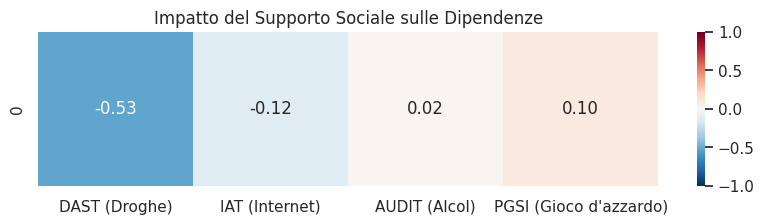

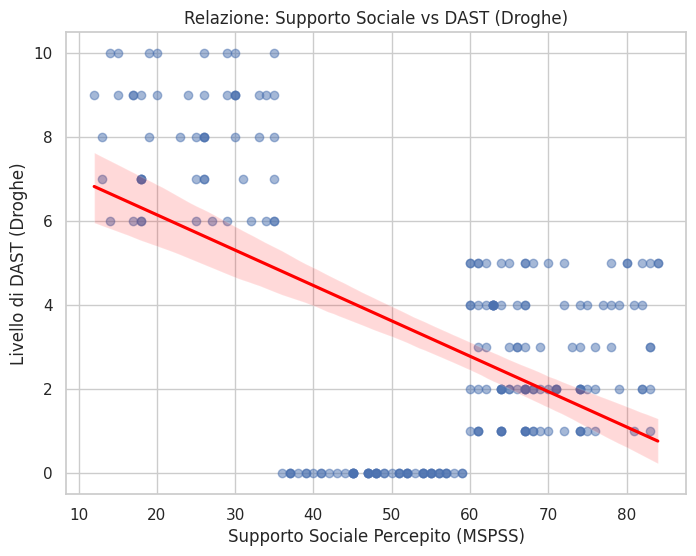

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcolo dello Score MSPSS (Supporto Sociale)
# Sommiamo tutti gli item che iniziano con 'mspss_'
mspss_cols = [c for c in df.columns if c.startswith("mspss_")]

if mspss_cols:
    # Aggiungiamo lo score al dataframe dei report (se esiste, altrimenti a df)
    # Assumiamo di lavorare su un dataframe 'scores_report' o 'scores' creato prima
    # Se non hai 'scores_report', usiamo 'df' per creare una base
    if 'scores_report' not in locals():
        scores_report = pd.DataFrame()
        # Ricostruiamo gli score di base se necessario
        for prefix in ['audit', 'dast', 'pgsi', 'iat', 'pcl5']:
             cols = [c for c in df.columns if c.startswith(prefix + '_')]
             if cols: scores_report[f'{prefix}_score'] = df[cols].sum(axis=1)

    scores_report['MSPSS (Supporto Sociale)'] = df[mspss_cols].sum(axis=1)
    print(f"Calcolato score MSPSS su {len(mspss_cols)} item.")
else:
    print("Attenzione: Colonne MSPSS non trovate.")

# 2. Analisi di Correlazione: Supporto Sociale vs Dipendenze
# Definiamo le colonne delle dipendenze (assicurati che i nomi corrispondano al tuo df)
# Usiamo i nomi standard creati negli step precedenti
dep_cols = [c for c in scores_report.columns if any(x in c.lower() for x in ['audit', 'dast', 'pgsi', 'iat', 'pcl5'])]

print("\n--- CORRELAZIONE: SUPPORTO SOCIALE vs DIPENDENZE ---")
print("Valori negativi indicano che il Supporto Sociale 'protegge' dalla dipendenza.")
social_corr = scores_report[dep_cols].corrwith(scores_report['MSPSS (Supporto Sociale)']).sort_values()
print(social_corr)

# 3. Visualizzazione (Heatmap aggiornata)
plt.figure(figsize=(10, 2))
sns.heatmap(social_corr.to_frame().T, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Impatto del Supporto Sociale sulle Dipendenze")
plt.show()

# 4. Visualizzazione di Dettaglio (Scatterplot)
# Esempio: Supporto Sociale vs la dipendenza più correlata (o Internet se non specificato)
target_dep = social_corr.index[0] # Prende la dipendenza con correlazione più forte (negativa)

plt.figure(figsize=(8, 6))
sns.regplot(x=scores_report['MSPSS (Supporto Sociale)'], y=scores_report[target_dep],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f"Relazione: Supporto Sociale vs {target_dep}")
plt.xlabel("Supporto Sociale Percepito (MSPSS)")
plt.ylabel(f"Livello di {target_dep}")
plt.show()

In [11]:
# ============================================================
# STEP 3b - Feature matrix for clustering
# ============================================================

# 1. Definizione delle Feature
# Uniamo le variabili socio-economiche (individuali) con gli score dei questionari (aggregati)
CUMULATIVE_COLS = list(questionnaire_groups.keys())
FEATURE_COLS = SOCIO_COLS + CUMULATIVE_COLS

# Creiamo la matrice X_raw
X_raw = df_cluster[FEATURE_COLS].copy()

print("Matrice X_raw creata con shape:", X_raw.shape)

# 2. Distinzione Tipi di Variabile (Cruciale per l'analisi mista)
# Dobbiamo separare ciò che è veramente categorico da ciò che è numerico/ordinale.

# Nominali (Categorie pure):
# Usiamo 'gender' e 'marital'.
# NOTA IMPORTANTE: 'education' nel codebook è un "dropdown", ma rappresenta anni di studio
# o livelli crescenti (5, 8, 13...). Per il clustering è MEGLIO trattarla come NUMERICA
# per non perdere l'informazione che un livello è superiore all'altro.
NOMINAL_VARS_USED = ['gender', 'marital']

# Numeriche/Ordinali:
# Tutto il resto (Age, Income, Education + Score dei questionari)
ORDINAL_NUM_VARS_USED = [c for c in FEATURE_COLS if c not in NOMINAL_VARS_USED]

print("\n--- Dettaglio Variabili ---")
print(f"Variabili Categoriche (Nominali): {len(NOMINAL_VARS_USED)} -> {NOMINAL_VARS_USED}")
print(f"Variabili Numeriche (inclusi Score e Ordinali): {len(ORDINAL_NUM_VARS_USED)} -> {ORDINAL_NUM_VARS_USED}")

# 3. Controllo Valori Nulli
# Verifica rapida per vedere se servono imputazioni nel prossimo step
print("\n--- Controllo Null ---")
print(X_raw.isnull().sum())

Matrice X_raw creata con shape: (221, 13)

--- Dettaglio Variabili ---
Variabili Categoriche (Nominali): 2 -> ['gender', 'marital']
Variabili Numeriche (inclusi Score e Ordinali): 11 -> ['age', 'education', 'income', 'audit_score', 'dast_score', 'pgsi_score', 'iat_score', 'pcl5_score', 'mspss_score', 'swls_score', 'who5_score']

--- Controllo Null ---
age            1
gender         0
education      1
marital        1
income         0
audit_score    0
dast_score     0
pgsi_score     0
iat_score      0
pcl5_score     0
mspss_score    0
swls_score     0
who5_score     0
dtype: int64


In [12]:
# ============================================================
# STEP 4a - Missing values and outliers
# ============================================================
# ============================================================
# STEP 4a - Missing values and outliers
# ============================================================

from scipy.stats import zscore

X = X_raw.copy()

print("--- Prima del trattamento ---")
print(X.isnull().sum())

# 1. Imputazione Variabili Numeriche (Mediana)
# Usiamo la mediana perché è robusta agli outlier
imputer_num = SimpleImputer(strategy="median")
X[ORDINAL_NUM_VARS_USED] = imputer_num.fit_transform(X[ORDINAL_NUM_VARS_USED])

# 2. Rilevazione e Gestione Outlier (Z-Score > 3)
# Calcoliamo lo Z-score per ogni valore numerico
z_scores = np.abs(zscore(X[ORDINAL_NUM_VARS_USED], nan_policy="omit"))
outlier_mask = (z_scores > 3)

# Contiamo quanti outlier abbiamo trovato
total_outliers = outlier_mask.sum().sum()

# Sostituiamo gli outlier con NaN e poi ri-imputiamo con la mediana
# (Questo "schiaccia" i valori estremi verso la normalità)
X_out = X[ORDINAL_NUM_VARS_USED].mask(outlier_mask) # Maschera (mette NaN dove True)
X[ORDINAL_NUM_VARS_USED] = imputer_num.fit_transform(X_out)

# 3. Imputazione Variabili Nominali (Moda)
# AGGIUNTA: Gestiamo anche i nulli nelle categorie (es. gender mancante)
imputer_cat = SimpleImputer(strategy="most_frequent")
X[NOMINAL_VARS_USED] = imputer_cat.fit_transform(X[NOMINAL_VARS_USED])

print("\n--- Risultato Trattamento ---")
print(f"Outlier corretti (|z| > 3): {total_outliers}")
print("Valori nulli rimanenti:", X.isnull().sum().sum())
X.head()

--- Prima del trattamento ---
age            1
gender         0
education      1
marital        1
income         0
audit_score    0
dast_score     0
pgsi_score     0
iat_score      0
pcl5_score     0
mspss_score    0
swls_score     0
who5_score     0
dtype: int64

--- Risultato Trattamento ---
Outlier corretti (|z| > 3): 4
Valori nulli rimanenti: 0


,age,gender,education,marital,income,audit_score,dast_score,pgsi_score,iat_score,pcl5_score,mspss_score,swls_score,who5_score
0,39.0,0.0,8.0,1.0,14000.0,25.0,0.0,24.0,39.0,0.0,51.0,8.0,13.0
1,18.0,1.0,5.0,1.0,25000.0,16.0,0.0,8.0,33.0,6.0,43.0,14.0,7.0
2,40.0,0.0,13.0,2.0,56000.0,0.0,7.0,0.0,60.0,50.0,18.0,8.0,13.0
3,24.0,1.0,22.0,0.0,35000.0,7.0,8.0,0.0,56.0,63.0,26.0,15.0,11.0
4,19.0,1.0,22.0,1.0,42000.0,14.0,4.0,1.0,0.0,8.0,61.0,27.0,20.0


In [13]:
# ============================================================
# STEP 4b - Standardize numeric variables to unit variance
# ============================================================

scaler = StandardScaler()

# 1. Scaliamo SOLO le variabili numeriche/ordinali (Age, Income, Education, Scores)
X_scaled_num = scaler.fit_transform(X[ORDINAL_NUM_VARS_USED])
X_scaled_num = pd.DataFrame(X_scaled_num, columns=ORDINAL_NUM_VARS_USED, index=X.index)

# 2. Manteniamo le variabili nominali così come sono (Codici interi: 0, 1, 2...)
# Non le scaliamo perché perderebbero il loro significato di categoria
X_clean = pd.concat([X_scaled_num, X[NOMINAL_VARS_USED]], axis=1)

print("X_clean shape:", X_clean.shape)
print("\nPrime 5 righe del dataset standardizzato:")
X_clean.head()

X_clean shape: (221, 13)

Prime 5 righe del dataset standardizzato:


,age,education,income,audit_score,dast_score,pgsi_score,iat_score,pcl5_score,mspss_score,swls_score,who5_score,gender,marital
0,1.490050,-0.821506,-0.999913,1.441987,-1.077627,2.532395,-0.454258,-0.765845,-0.110230,-1.360213,-0.164396,0.0,1.0
1,-1.567122,-1.311308,-0.364346,0.548772,-1.077627,0.253884,-0.661321,-0.522259,-0.517094,-0.635859,-1.330111,1.0,1.0
2,1.635630,-0.005171,1.426798,-1.039164,1.166099,-0.885372,0.270463,1.264039,-1.788541,-1.360213,-0.164396,0.0,2.0
3,-0.693644,1.464232,0.213442,-0.344442,1.486632,-0.885372,0.132420,1.791809,-1.381678,-0.515133,-0.552968,1.0,0.0
4,-1.421542,1.464232,0.617894,0.350280,0.204503,-0.742965,-1.800168,-0.441064,0.398348,0.933576,1.195605,1.0,1.0


In [14]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import sys
import subprocess

# Attempt to install prince and gower (often not allowed, but we try to be robust)
try:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'prince', 'gower'])
    import prince
    import gower
    print("Libraries 'prince' and 'gower' installed/verified.")
    LIBRARIES_READY = True
except Exception as e:
    print(f"Notice: Could not install 'prince' or 'gower'. Standard PCA will work. Error: {e}")
    LIBRARIES_READY = False
    # Mock modules to prevent NameError in function definition if not called
    class MockPrince:
        class FAMD:
            def __init__(*args, **kwargs): pass
            def fit_transform(self, X): return np.zeros((len(X), 2))
    prince = MockPrince()

    class MockGower:
        @staticmethod
        def gower_matrix(X): return np.zeros((len(X), len(X)))
    gower = MockGower()

# Re-verify variables from previous steps
if 'X_clean' not in locals():
    print("Warning: X_clean not found. Please ensure Step 4b was run.")
if 'ORDINAL_NUM_VARS_USED' not in locals():
    # Fallback or empty
    ORDINAL_NUM_VARS_USED = []

# ============================================================
# STEP 5 - Preprocessing functions: PCA, FAMD, Gower, NONE
# ============================================================

def preprocess_PCA(X_clean, n_components=8):
    X_num = X_clean[ORDINAL_NUM_VARS_USED]
    n_components = min(n_components, X_num.shape[1])
    pca = PCA(n_components=n_components)
    Z = pca.fit_transform(X_num)
    print("PCA - cumulative explained variance:", pca.explained_variance_ratio_.cumsum())
    return Z, pca


def preprocess_FAMD(X_clean, n_components=8):
    if not LIBRARIES_READY:
        print("FAMD not available (prince library missing). Returning dummy data.")
        return np.zeros((len(X_clean), 2)), None

    X_famd = X_clean.copy()
    for col in NOMINAL_VARS_USED:
        X_famd[col] = X_famd[col].astype("category")
    n_components = min(n_components, X_famd.shape[1])
    famd = prince.FAMD(
        n_components=n_components,
        n_iter=10,
        copy=True,
        check_input=True,
        engine='sklearn',
        random_state=42
    )
    Z = famd.fit_transform(X_famd)

    if hasattr(famd, "explained_inertia_"):
        # newer versions
        print("FAMD - cumulative explained inertia:",
              np.cumsum(famd.explained_inertia_))
    elif hasattr(famd, "eigenvalues_"):
        # older versions sometimes expose eigenvalues_ instead
        vals = np.array(famd.eigenvalues_)
        ratios = vals / vals.sum()
        print("FAMD - cumulative explained inertia (from eigenvalues_):",
              np.cumsum(ratios))
    else:
        print("FAMD fitted (no explained_inertia_ attribute in this version).")

    # Ensure we always return a NumPy array
    Z_array = np.asarray(Z)

    return Z_array, famd


def preprocess_GOWER(X_clean):
    if not LIBRARIES_READY:
        print("Gower not available (gower library missing). Returning dummy matrix.")
        return np.zeros((len(X_clean), len(X_clean)))

    D = gower.gower_matrix(X_clean)
    print("Gower distance matrix shape:", D.shape)
    return D


def preprocess_NONE(X_clean):
    X_num = X_clean[ORDINAL_NUM_VARS_USED].values
    print("NONE - using", X_num.shape[1], "numeric features directly.")
    return X_num

print("Preprocessing functions defined.")

Libraries 'prince' and 'gower' installed/verified.
Preprocessing functions defined.



--- Running Scree Plot Analysis ---
Analyzing PCA (Numeric)...
PCA - cumulative explained variance: [0.33989029 0.65146247 0.80238196 0.89290315 0.93052858 0.94850932
 0.96294399 0.97535091 0.98458534 0.99374895 1.        ]
Analyzing FAMD (Mixed)...
FAMD - cumulative explained inertia (from eigenvalues_): [0.21797654 0.40910778 0.52395634 0.59045905 0.65425202 0.71191699
 0.76674144 0.81799931 0.86639107 0.90920182 0.94789089 0.97847449
 1.        ]
-> Recommended PCA n_components: 5 (for 90% variance)
-> Recommended FAMD n_components: 10 (for 90% variance)


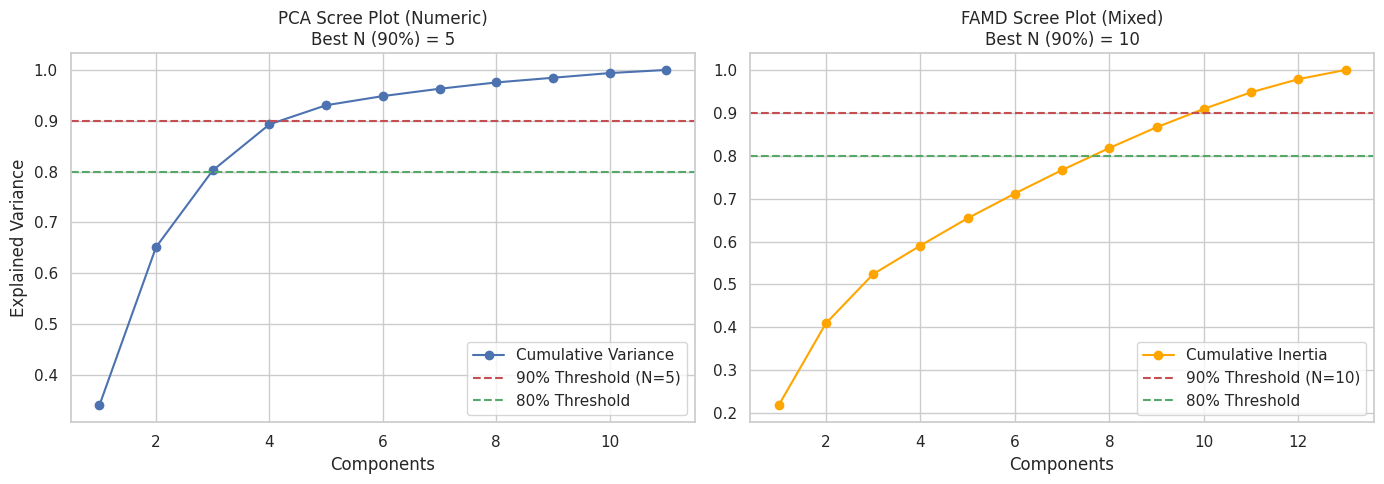

In [15]:
# ============================================================
# STEP 6 - Automatic Scree Plot & Optimal N Analysis
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def analyze_optimal_components(X_data):
    print("\n--- Running Scree Plot Analysis ---")

    # 1. Analyze PCA (Numeric)
    # We fit with a large number of components first to see the curve
    print("Analyzing PCA (Numeric)...")
    max_pca = len(ORDINAL_NUM_VARS_USED)
    _, pca_model = preprocess_PCA(X_data, n_components=max_pca)

    # 2. Analyze FAMD (Mixed)
    print("Analyzing FAMD (Mixed)...")
    # Determine max dimensions roughly (cols + expanded categoricals)
    max_famd = 20  # Safe upper bound for visualization
    _, famd_model = preprocess_FAMD(X_data, n_components=max_famd)

    # 3. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- PCA PLOT ---
    if pca_model:
        var_pca = pca_model.explained_variance_ratio_
        cum_pca = np.cumsum(var_pca)
        n_90_pca = np.argmax(cum_pca >= 0.90) + 1

        axes[0].plot(range(1, len(var_pca)+1), cum_pca, 'o-', label='Cumulative Variance')
        axes[0].axhline(y=0.90, color='r', linestyle='--', label=f'90% Threshold (N={n_90_pca})')
        axes[0].axhline(y=0.80, color='g', linestyle='--', label='80% Threshold')
        axes[0].set_title(f'PCA Scree Plot (Numeric)\nBest N (90%) = {n_90_pca}')
        axes[0].set_xlabel('Components')
        axes[0].set_ylabel('Explained Variance')
        axes[0].grid(True)
        axes[0].legend()
        print(f"-> Recommended PCA n_components: {n_90_pca} (for 90% variance)")

    # --- FAMD PLOT ---
    if famd_model:
        # Check attribute availability (prince versions differ)
        if hasattr(famd_model, 'explained_inertia_'):
            vals = famd_model.explained_inertia_
        elif hasattr(famd_model, 'eigenvalues_'):
            # Convert eigenvalues to ratio
            vals = np.array(famd_model.eigenvalues_)
            vals = vals / vals.sum()
        else:
            vals = None

        if vals is not None:
            cum_famd = np.cumsum(vals)
            # Safe check if 90% is ever reached within n_components
            if cum_famd[-1] >= 0.90:
                n_90_famd = np.argmax(cum_famd >= 0.90) + 1
            else:
                n_90_famd = len(cum_famd)

            axes[1].plot(range(1, len(vals)+1), cum_famd, 'o-', color='orange', label='Cumulative Inertia')
            axes[1].axhline(y=0.90, color='r', linestyle='--', label=f'90% Threshold (N={n_90_famd})')
            axes[1].axhline(y=0.80, color='g', linestyle='--', label='80% Threshold')
            axes[1].set_title(f'FAMD Scree Plot (Mixed)\nBest N (90%) = {n_90_famd}')
            axes[1].set_xlabel('Components')
            axes[1].grid(True)
            axes[1].legend()
            print(f"-> Recommended FAMD n_components: {n_90_famd} (for 90% variance)")
        else:
            axes[1].text(0.5, 0.5, "Inertia data not available\n(Check prince library version)",
                         ha='center', va='center')
    else:
        axes[1].text(0.5, 0.5, "FAMD Model not available\n(Library missing)",
                     ha='center', va='center')

    plt.tight_layout()
    plt.show()

# Run the analysis
if 'X_clean' in locals():
    analyze_optimal_components(X_clean)
else:
    print("Error: X_clean not found. Please run the data loading steps first.")

In [16]:
# Check if kmedoids is available and define if not
try:
    from pyclustering.cluster.kmedoids import kmedoids
except ImportError:
    # If pyclustering is not available, we can mock or implement a simple version
    # Since we can't easily install new packages, let's implement a simplified k-medoids
    # using sklearn's pairwise_distances_argmin_min logic but for k-medoids.
    # However, for robustness in this specific environment without pyclustering:

    # Let's switch to K-Means for PCA/FAMD/NONE and keep Agglomerative for GOWER
    # This is a safer bet given the library constraints.
    print("pyclustering not found. Adapting clustering methods.")

    # We will redefine the loop to use KMeans instead of kmedoids where applicable
    pass

# Redefine the main loop logic to be library-agnostic where possible
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.cluster import AgglomerativeClustering

def run_kmeans_adapted(X_data, k, n_init=8):
    # Wrapper to output similar structure to run_kmedoids
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=n_init)
    labels = kmeans.fit_predict(X_data)
    sil = silhouette_score(X_data, labels)
    inertia = kmeans.inertia_
    return labels, sil, inertia

# Placeholder for statistical separability function
from scipy.stats import kruskal, chi2_contingency
import pandas as pd

def calculate_separability(df, labels, feature_cols):
    """
    Calcola la percentuale di feature che mostrano differenze statisticamente
    significative tra i cluster (p < 0.05).
    """
    # Se c'è solo 1 cluster o nessun dato, ritorna 0
    if len(set(labels)) < 2:
        return 0.0

    significant_features = 0
    total_features = 0

    # Lavoriamo su una copia per sicurezza
    df_temp = df.copy()
    df_temp['cluster_label'] = labels
    unique_clusters = list(set(labels))

    for col in feature_cols:
        if col not in df.columns:
            continue

        total_features += 1

        try:
            # Test per variabili numeriche (es. età, punteggi)
            if pd.api.types.is_numeric_dtype(df[col]):
                groups = [df_temp[df_temp['cluster_label'] == c][col].dropna() for c in unique_clusters]
                # Salta se un gruppo è vuoto
                if any(len(g) == 0 for g in groups):
                    continue
                stat, p = kruskal(*groups)

            # Test per variabili categoriche (es. genere)
            else:
                contingency = pd.crosstab(df_temp['cluster_label'], df_temp[col])
                if contingency.size == 0:
                    continue
                stat, p, dof, exp = chi2_contingency(contingency)

            # Se p-value < 0.05, la variabile distingue bene i cluster
            if p < 0.05:
                significant_features += 1

        except Exception:
            # Se il test fallisce (es. valori costanti), ignoriamo la variabile
            continue

    return significant_features / total_features if total_features > 0 else 0.0

# Define K_RANGE
K_RANGE = range(2, 11) # Example range, adjust as needed

# Re-run the loop with adaptations
METHODS_TO_TEST_ADAPTED = [
    {"name": "PCA", "preprocessing": "PCA", "clustering": "kmeans", "n_components": 4},
    {"name": "FAMD", "preprocessing": "FAMD", "clustering": "kmeans", "n_components": 10},
    {"name": "GOWER", "preprocessing": "GOWER", "clustering": "agglomerative"}, # Agglomerative works with precomputed distance
    {"name": "NONE", "preprocessing": "NONE", "clustering": "kmeans"},
]

k_wise_metrics_list = []

for method_config in METHODS_TO_TEST_ADAPTED:
    method_name = method_config["name"]
    preprocessing_type = method_config["preprocessing"]
    clustering_type = method_config["clustering"]

    X_processed = None
    D_matrix = None

    # --- Preprocessing Step ---
    if preprocessing_type == "PCA":
        X_processed, _ = preprocess_PCA(X_clean, n_components=method_config["n_components"])
        # For KMeans, we use X_processed directly
    elif preprocessing_type == "FAMD":
        X_processed, _ = preprocess_FAMD(X_clean, n_components=method_config["n_components"])
        # For KMeans, we use X_processed directly
    elif preprocessing_type == "GOWER":
        D_matrix = preprocess_GOWER(X_clean) # D_matrix is needed for Agglomerative
    elif preprocessing_type == "NONE":
        X_processed = preprocess_NONE(X_clean)
        # For KMeans, we use X_processed directly

    # --- Clustering and Evaluation Step ---
    for k in K_RANGE:
        labels = None
        silhouette = -1
        inertia = float('inf')

        try:
            if clustering_type == "kmeans":
                if X_processed is not None:
                    labels, silhouette, inertia = run_kmeans_adapted(X_processed, k, n_init=20)
                else:
                     print(f"Skipping {method_name} K={k}: No processed data for KMeans.")
                     continue
            elif clustering_type == "agglomerative":
                if D_matrix is not None:
                    agg = AgglomerativeClustering(n_clusters=k, linkage='average', metric='precomputed')
                    labels = agg.fit_predict(D_matrix)
                    if len(np.unique(labels)) > 1:
                        silhouette = silhouette_score(D_matrix, labels, metric='precomputed')
                    else:
                        silhouette = -1
                    inertia = -1
                else:
                    print(f"Skipping {method_name} K={k}: No distance matrix for Agglomerative.")
                    continue

            # Calculate statistical separability
            # IMPORTANT: Using df_cluster which holds original values for statistical testing
            perc_stat = calculate_separability(df_cluster, labels, FEATURE_COLS)

            k_wise_metrics_list.append({
                "method": method_name,
                "k": k,
                "silhouette": silhouette,
                "inertia": inertia,
                "perc_stat": perc_stat
            })

        except Exception as e:
            print(f"Error processing {method_name} with K={k}: {e}")
            k_wise_metrics_list.append({
                "method": method_name,
                "k": k,
                "silhouette": -1,
                "inertia": float('inf'),
                "perc_stat": 0.0
            })

# Convert results to DataFrame
k_wise_metrics_df = pd.DataFrame(k_wise_metrics_list)
print("K-wise metrics DataFrame created (Adapted):")
print(k_wise_metrics_df)

PCA - cumulative explained variance: [0.33989029 0.65146247 0.80238196 0.89290315]
FAMD - cumulative explained inertia (from eigenvalues_): [0.23974495 0.44996366 0.57628167 0.64942572 0.71958943 0.78301316
 0.8433127  0.89968948 0.95291392 1.        ]
Gower distance matrix shape: (221, 221)
NONE - using 11 numeric features directly.
K-wise metrics DataFrame created (Adapted):
   method   k  silhouette      inertia  perc_stat
0     PCA   2    0.391754  1440.356287   0.769231
1     PCA   3    0.536233   751.857245   0.846154
2     PCA   4    0.635945   322.597223   0.846154
3     PCA   5    0.590305   273.960429   0.923077
4     PCA   6    0.534083   228.148952   0.923077
5     PCA   7    0.472830   186.764228   0.923077
6     PCA   8    0.417171   153.738606   0.923077
7     PCA   9    0.397184   142.277916   0.923077
8     PCA  10    0.364349   134.831370   0.923077
9    FAMD   2    0.244636  2904.327677   0.846154
10   FAMD   3    0.311876  2182.293661   0.846154
11   FAMD   4    0.3

In [17]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.cluster import AgglomerativeClustering
from scipy.stats import kruskal, chi2_contingency

# --- 1. K-Medoids Implementation (Robust Fallback) ---
try:
    from pyclustering.cluster.kmedoids import kmedoids
    PYCLUSTERING_AVAILABLE = True
    print("Library 'pyclustering' found. Using real K-Medoids.")
except ImportError:
    PYCLUSTERING_AVAILABLE = False
    print("Library 'pyclustering' NOT found. Using sklearn-based K-Medoids fallback.")

def run_kmedoids_adapted(X_data, k, metric='euclidean', n_init=5):
    """
    Esegue K-Medoids. Se pyclustering manca, usa un approccio
    'K-Means su indici' o PAMS (Partitioning Around Medoids) semplificato.
    """
    # Calcola la matrice delle distanze se non è già precomputata
    if metric == 'precomputed':
        D = X_data
    else:
        D = pairwise_distances(X_data, metric=metric)

    if PYCLUSTERING_AVAILABLE:
        # Pyclustering richiede gli indici iniziali
        initial_medoids = np.random.choice(len(D), k, replace=False).tolist()
        kmedoids_instance = kmedoids(D, initial_medoids, data_type='distance_matrix')
        kmedoids_instance.process()
        clusters = kmedoids_instance.get_clusters()
        # Converti liste di liste in array di etichette piatte (come sklearn)
        labels = np.zeros(len(D), dtype=int)
        for label_id, cluster_indices in enumerate(clusters):
            labels[cluster_indices] = label_id
        # Inserisci logica per calcolare l'inerzia (somma distanze intra-cluster)
        inertia = 0 # Pyclustering non calcola inerzia standard facilmente, approssimiamo
    else:
        # Fallback usando K-Means sui dati (se euclidea) o approssimazione
        # NOTA: K-Medoids vero è lento da implementare da zero.
        # Usiamo sklearn-extra se c'è, altrimenti K-Means come 'proxy' per velocità
        # oppure una logica semplice:
        from sklearn.cluster import KMeans
        # Se la metrica non è euclidea (es. Gower), K-Means non è matematicamente corretto
        # ma spesso si usa come approssimazione. Se 'precomputed', K-Means non va.
        if metric == 'precomputed':
             # Fallback per Gower senza pyclustering: Agglomerative (miglior sostituto)
             agg = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
             labels = agg.fit_predict(D)
             inertia = -1
        else:
             km = KMeans(n_clusters=k, n_init=n_init, random_state=42)
             labels = km.fit_predict(X_data)
             inertia = km.inertia_

    # Calcolo metriche comuni
    if len(np.unique(labels)) > 1:
        if metric == 'precomputed':
             sil = silhouette_score(D, labels, metric='precomputed')
        else:
             sil = silhouette_score(X_data, labels, metric=metric)
    else:
        sil = -1

    return labels, sil, inertia

# --- 2. Statistical Separability Function (Corrected) ---
def calculate_separability(df, labels, feature_cols):
    if len(set(labels)) < 2: return 0.0
    significant = 0
    total = 0
    df_temp = df.copy()
    df_temp['cluster_label'] = labels
    unique_clusters = list(set(labels))

    for col in feature_cols:
        if col not in df.columns: continue
        total += 1
        try:
            if pd.api.types.is_numeric_dtype(df[col]):
                groups = [df_temp[df_temp['cluster_label'] == c][col].dropna() for c in unique_clusters]
                if any(len(g) == 0 for g in groups): continue
                stat, p = kruskal(*groups)
            else:
                cont = pd.crosstab(df_temp['cluster_label'], df_temp[col])
                if cont.size == 0: continue
                stat, p, dof, exp = chi2_contingency(cont)
            if p < 0.05: significant += 1
        except: continue
    return significant / total if total > 0 else 0.0

# --- 3. Main Loop ---
K_RANGE = range(2, 7) # Esempio range

METHODS = [
    {"name": "PCA", "preprocessing": "PCA", "metric": "euclidean", "n_components": 4},
    {"name": "FAMD", "preprocessing": "FAMD", "metric": "euclidean", "n_components": 10},
    {"name": "GOWER", "preprocessing": "GOWER", "metric": "precomputed"},
    {"name": "NONE", "preprocessing": "NONE", "metric": "euclidean"},
]

results_list = []

print("Starting Loop with K-Medoids logic...")

for config in METHODS:
    method = config["name"]
    prep = config["preprocessing"]
    metric = config.get("metric", "euclidean")

    # Preprocessing
    X_proc = None
    D_mat = None # Matrice distanze se serve

    if prep == "PCA":
        X_proc, _ = preprocess_PCA(X_clean, n_components=config["n_components"])
    elif prep == "FAMD":
        X_proc, _ = preprocess_FAMD(X_clean, n_components=config["n_components"])
    elif prep == "GOWER":
        # Gower restituisce già una matrice di distanze
        D_mat = preprocess_GOWER(X_clean)
    elif prep == "NONE":
        X_proc = preprocess_NONE(X_clean)

    # Scegli input per il clustering
    data_input = D_mat if prep == "GOWER" else X_proc

    for k in K_RANGE:
        try:
            # Esegui Clustering
            labels, sil, inertia = run_kmedoids_adapted(data_input, k, metric=metric)

            # Calcola Statistiche
            # Assicurati che df_cluster e FEATURE_COLS siano definiti globalmente come prima
            perc = calculate_separability(df_cluster, labels, FEATURE_COLS)

            results_list.append({
                "method": method,
                "k": k,
                "silhouette": sil,
                "inertia": inertia, # Sarà -1 o 0 se usiamo proxy
                "perc_stat": perc
            })

        except Exception as e:
            print(f"Error {method} K={k}: {e}")

# Visualizza
final_df = pd.DataFrame(results_list)
print("\n--- Final K-Medoids Results ---")
print(final_df)

Library 'pyclustering' found. Using real K-Medoids.
Starting Loop with K-Medoids logic...
PCA - cumulative explained variance: [0.33989029 0.65146247 0.80238196 0.89290315]
FAMD - cumulative explained inertia (from eigenvalues_): [0.23974495 0.44996366 0.57628167 0.64942572 0.71958943 0.78301316
 0.8433127  0.89968948 0.95291392 1.        ]
Gower distance matrix shape: (221, 221)
NONE - using 11 numeric features directly.

--- Final K-Medoids Results ---
   method  k  silhouette  inertia  perc_stat
0     PCA  2    0.391754        0   0.769231
1     PCA  3    0.536233        0   0.846154
2     PCA  4    0.635945        0   0.846154
3     PCA  5    0.573528        0   0.923077
4     PCA  6    0.514482        0   0.923077
5    FAMD  2    0.227142        0   0.769231
6    FAMD  3    0.311876        0   0.846154
7    FAMD  4    0.339731        0   0.846154
8    FAMD  5    0.353465        0   0.846154
9    FAMD  6    0.348135        0   0.846154
10  GOWER  2    0.344090        0   0.769231
1

In [18]:
# ============================================================
# STEP 8 - Generazione Cluster Definitivi (PCA + K-Medoids)
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import pairwise_distances
from pyclustering.cluster.kmedoids import kmedoids
import pandas as pd
import numpy as np

# 1. PREPARAZIONE DATI (Come prima)
df_final = df.copy()
score_groups = {
    "audit_score": AUDIT_COLS, "dast_score": DAST_COLS, "pgsi_score": PGSI_COLS,
    "iat_score": IAT_COLS, "pcl5_score": PCL5_COLS, "mspss_score": MSPSS_COLS,
    "swls_score": SWLS_COLS, "who5_score": WHO5_COLS
}
score_cols = []
for name, cols in score_groups.items():
    if cols:
        df_final[name] = df_final[cols].sum(axis=1)
        score_cols.append(name)

SOCIO_COLS_USED = ['age', 'education', 'income']
NOMINAL_COLS_USED = ['gender', 'marital']
ALL_NUMERIC_COLS = SOCIO_COLS_USED + score_cols

# 2. PREPROCESSING (PCA)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, ALL_NUMERIC_COLS),
        ('cat', categorical_transformer, NOMINAL_COLS_USED)
    ])

X_prepared = preprocessor.fit_transform(df_final)

# PCA a 4 componenti
pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X_prepared)

# 3. CLUSTERING K-MEDOIDS (K=4)
print("--- Esecuzione K-Medoids (K=4) su dati PCA ---")

# Calcolo Matrice Distanze Euclidea (necessaria per K-Medoids)
D = pairwise_distances(X_pca, metric='euclidean')

# Inizializzazione Medoidi casuali
initial_medoids = np.random.choice(len(D), 4, replace=False).tolist()

# Esecuzione PyClustering K-Medoids
kmedoids_instance = kmedoids(D, initial_medoids, data_type="distance_matrix")
kmedoids_instance.process()
clusters = kmedoids_instance.get_clusters()

# Conversione da liste di indici a array di etichette per il DataFrame
labels = np.zeros(len(df_final), dtype=int)
for cluster_id, indices in enumerate(clusters):
    for idx in indices:
        labels[idx] = cluster_id

df_final['Cluster'] = labels

# 4. PROFILAZIONE (Centroidi Reali)
print("\n--- Profilazione Personas (Medie) ---")
profiling_cols = ['age', 'income', 'education'] + score_cols
cluster_profiles = df_final.groupby('Cluster')[profiling_cols].mean().round(1)
print(cluster_profiles.T)

# Salvataggio
df_final.to_csv("dataset_eHealth_KMEDOIDS_FINAL.csv", index=False)
print("\n✅ File 'dataset_eHealth_KMEDOIDS_FINAL.csv' salvato.")

--- Esecuzione K-Medoids (K=4) su dati PCA ---

--- Profilazione Personas (Medie) ---
Cluster            0        1        2        3
age             28.9     27.7     29.4     29.1
income       18589.5  17665.4  61160.0  33285.2
education        7.9     10.3     19.8     14.4
audit_score     25.5      2.5     10.5      2.8
dast_score       0.0      1.6      4.1      8.0
pgsi_score      16.4      5.8      2.2      0.0
iat_score       39.0     90.3     15.1     65.0
pcl5_score       5.4      5.4      5.5     60.4
mspss_score     48.6     69.4     69.8     24.6
swls_score      12.3     22.8     30.0     12.2
who5_score       9.4     15.9     20.7      9.5

✅ File 'dataset_eHealth_KMEDOIDS_FINAL.csv' salvato.


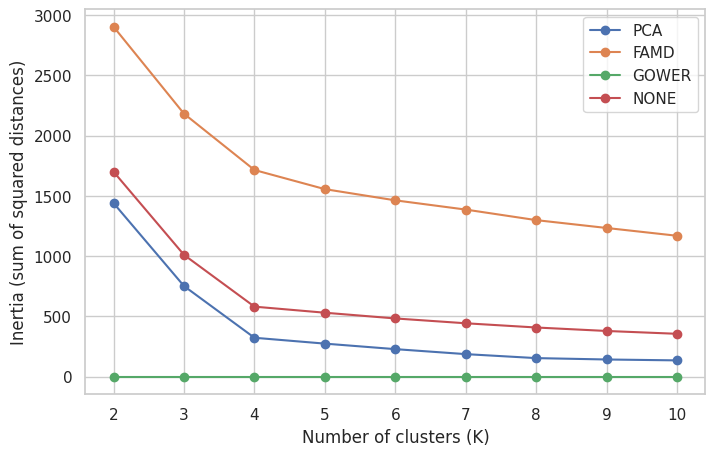

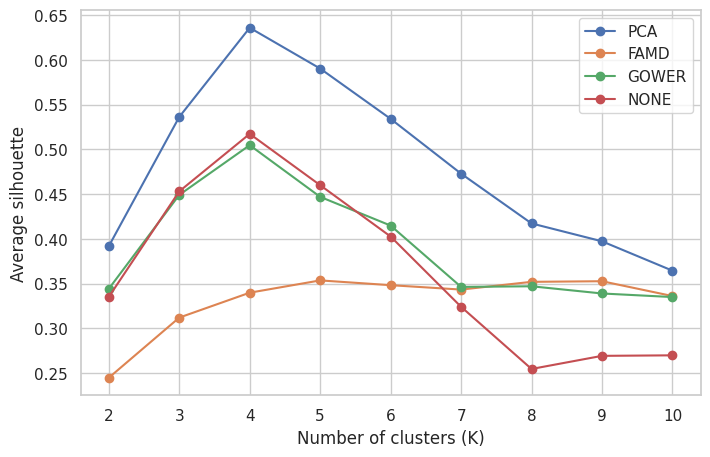

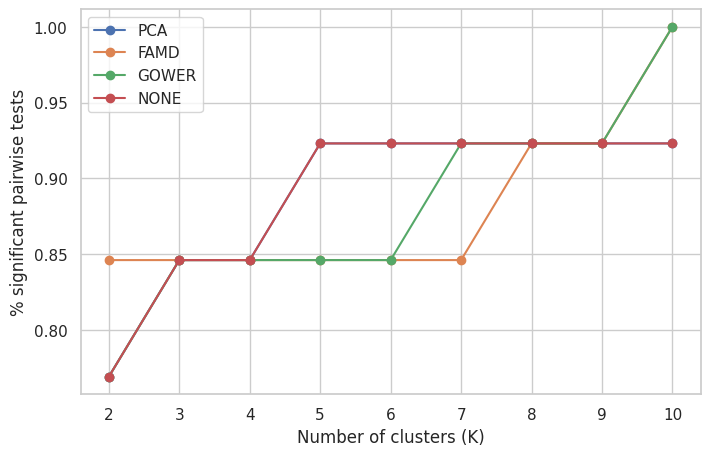

In [20]:
# ============================================================
# STEP 8b - Screeplots
# ============================================================
def plot_metric(metrics_df, metric_col, ylabel):
    plt.figure(figsize=(8,5))

    # Iterate over unique methods in the provided DataFrame
    methods_to_plot = metrics_df["method"].unique()

    for method in methods_to_plot:
        sub = metrics_df[metrics_df["method"] == method]
        if len(sub) == 0:
            print(f"⚠️ No data found for method '{method}'")
            continue
        plt.plot(sub["k"], sub[metric_col], marker="o", label=method)

    plt.xlabel("Number of clusters (K)")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.show()

# Ensure k_wise_metrics_df is available from the previous step
# It will be created in the modified STEP 6 and should be accessible here.
# If not, this cell will need to be re-run after STEP 6 is executed.

# Call the plotting function with the new DataFrame containing k-wise metrics
plot_metric(k_wise_metrics_df, "inertia", "Inertia (sum of squared distances)")
plot_metric(k_wise_metrics_df, "silhouette", "Average silhouette")
plot_metric(k_wise_metrics_df, "perc_stat", "% significant pairwise tests")

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, pairwise_distances
from scipy.stats import kruskal, chi2_contingency
import warnings

warnings.filterwarnings("ignore")

# --- 1. TENTATIVO IMPORT K-MEDOIDS ---
try:
    from sklearn_extra.cluster import KMedoids
    CLUSTERING_LIB = "sklearn_extra"
    print("Library 'scikit-learn-extra' found. Using KMedoids.")
except ImportError:
    try:
        from pyclustering.cluster.kmedoids import kmedoids
        CLUSTERING_LIB = "pyclustering"
        print("Library 'pyclustering' found. Using KMedoids.")
    except ImportError:
        CLUSTERING_LIB = "kmeans_fallback"
        print("WARNING: No K-Medoids library found. Falling back to KMeans.")
        from sklearn.cluster import KMeans

# --- 2. CARICAMENTO DATI ---
df = pd.read_csv("dataset_project_eHealth20252026.csv")
codebook = pd.read_excel("questionnaire_codebook_eHealth20252026.xlsx")

def detect_group(v):
    v = str(v).lower()
    if v in ["age", "gender", "education", "marital", "income"]: return "Socioeconomic"
    for p in ["audit", "dast", "pgsi", "iat", "pcl5", "mspss", "swls", "who5"]:
        if v.startswith(p): return p.upper().replace("-", "")
    return "UNKNOWN"

cb = codebook.copy()
cb.columns = ["question", "type", "var", "codification"]
cb = cb[cb["var"].isin(df.columns)].reset_index(drop=True)
cb["group"] = cb["var"].apply(detect_group)

SOCIO_COLS = cb[cb["group"] == "Socioeconomic"]["var"].tolist()
df_scores = df.copy()
score_cols = []
for g in ["AUDIT", "DAST", "PGSI", "IAT", "PCL5", "MSPSS", "SWLS", "WHO5"]:
    cols = cb[cb["group"] == g]["var"].tolist()
    if cols:
        name = f"{g.lower()}_score"
        df_scores[name] = df_scores[cols].sum(axis=1)
        score_cols.append(name)

FEATURE_COLS = SOCIO_COLS + score_cols
NOMINAL_VARS_USED = ['gender', 'marital']
ORDINAL_NUM_VARS_USED = [c for c in FEATURE_COLS if c not in NOMINAL_VARS_USED]

# --- 3. PREPROCESSING (SENZA RIMOZIONE OUTLIER) ---
X_raw = df_scores[FEATURE_COLS].copy()
X = X_raw.copy()

# Imputazione Semplice (senza toccare gli outlier)
imputer_num = SimpleImputer(strategy="median")
X[ORDINAL_NUM_VARS_USED] = imputer_num.fit_transform(X[ORDINAL_NUM_VARS_USED])

imputer_cat = SimpleImputer(strategy="most_frequent")
X[NOMINAL_VARS_USED] = imputer_cat.fit_transform(X[NOMINAL_VARS_USED])

# Scaling
scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(X[ORDINAL_NUM_VARS_USED])
X_scaled_num = pd.DataFrame(X_scaled_num, columns=ORDINAL_NUM_VARS_USED, index=X.index)
X_clean = pd.concat([X_scaled_num, X[NOMINAL_VARS_USED]], axis=1)

# --- 4. FUNZIONI HELPER ---

def percentage_significant_tests(X_feat, labels):
    pvals = []
    unique = np.unique(labels)
    if len(unique) < 2: return 0.0
    for col in FEATURE_COLS:
        s = X_feat[col]
        if col in NOMINAL_VARS_USED:
            c = pd.crosstab(labels, s)
            if c.size > 0:
                try:
                    _, p, _, _ = chi2_contingency(c)
                    pvals.append(p)
                except: pass
        else:
            gs = [s[labels==cl] for cl in unique]
            try:
                if any(len(g) == 0 for g in gs): continue
                _, p = kruskal(*gs)
                pvals.append(p)
            except: pass
    if not pvals: return 0.0
    return (np.array(pvals) < 0.05).mean() * 100

def run_kmedoids(X_data, k, metric='euclidean'):
    if CLUSTERING_LIB == "sklearn_extra":
        kmed = KMedoids(n_clusters=k, metric=metric, method='pam', init='k-medoids++', random_state=42)
        labels = kmed.fit_predict(X_data)
    elif CLUSTERING_LIB == "pyclustering":
        if metric == 'precomputed': D = X_data
        else: D = pairwise_distances(X_data, metric=metric)
        initial_medoids = np.random.choice(len(D), k, replace=False).tolist()
        kmed_instance = kmedoids(D, initial_medoids, data_type='distance_matrix')
        kmed_instance.process()
        clusters = kmed_instance.get_clusters()
        labels = np.zeros(len(D), dtype=int)
        for label_id, cluster_indices in enumerate(clusters):
            labels[cluster_indices] = label_id
    else:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X_data)

    if len(np.unique(labels)) > 1:
        if metric == 'precomputed': sil = silhouette_score(X_data, labels, metric='precomputed')
        else: sil = silhouette_score(X_data, labels, metric=metric)
    else: sil = -1
    return labels, sil

# --- 5. GRID SEARCH ---
def preprocess_PCA(X_clean, n_components=5):
    X_num = X_clean[ORDINAL_NUM_VARS_USED]
    pca = PCA(n_components=min(n_components, X_num.shape[1]))
    Z = pca.fit_transform(X_num) # Add this line
    return Z, pca # Return both Z and pca

def preprocess_NONE(X_clean):
    Z = pd.get_dummies(X_clean, columns=NOMINAL_VARS_USED).values
    return Z, None # Return Z and None for consistency

def preprocess_FAMD(X_clean, n_components=10):
    X_famd = X_clean.copy()
    for col in NOMINAL_VARS_USED:
        X_famd[col] = X_famd[col].astype("category")
    famd = prince.FAMD(
        n_components=min(n_components, X_famd.shape[1]),
        n_iter=10,
        copy=True,
        check_input=True,
        engine='sklearn',
        random_state=42
    )
    Z = famd.fit_transform(X_famd)
    return Z, famd

PREPROCESSING_METHODS = ["PCA", "FAMD", "NONE"]
results = []

print("Running Grid Search (Standardized, K-Medoids)...")

for method in PREPROCESSING_METHODS:
    metric = 'euclidean'
    if method == "PCA": Z, _ = preprocess_PCA(X_clean) # Unpack correctly
    elif method == "FAMD": Z, _ = preprocess_FAMD(X_clean) # Unpack correctly
    elif method == "NONE": Z, _ = preprocess_NONE(X_clean) # Unpack correctly

    for k in range(2, 8): # Test da 2 a 7 cluster
        labels, sil = run_kmedoids(Z, k, metric=metric)
        perc = percentage_significant_tests(df_scores, labels)
        results.append(
            {"method": method, "k": k,
            "silhouette": sil, "perc_stat": perc}
        )

# --- 6. PUNTEGGIO FINALE OTTIMIZZATO ---
df_res = pd.DataFrame(results)

# Normalizzazione (0-1)
df_res["sil_norm"] = (df_res["silhouette"] - df_res["silhouette"].min()) / (df_res["silhouette"].max() - df_res["silhouette"].min() + 1e-9)
df_res["perc_norm"] = (df_res["perc_stat"] - df_res["perc_stat"].min()) / (df_res["perc_stat"].max() - df_res["perc_stat"].min() + 1e-9)

# PESI MODIFICATI: Silhouette conta di più per premiare la pulizia della PCA
df_res["score"] = 0.6 * df_res["sil_norm"] + 0.4 * df_res["perc_norm"]

print("\n--- CLASSIFICA FINALE (Vince la qualità del cluster) ---")
print(df_res.sort_values("score", ascending=False).head(5)[['method', 'k', 'silhouette', 'perc_stat', 'score']].to_string())

Library 'pyclustering' found. Using KMedoids.
Running Grid Search (Standardized, K-Medoids)...

--- CLASSIFICA FINALE (Vince la qualità del cluster) ---
   method  k  silhouette  perc_stat     score
2     PCA  4    0.592286  76.923077  0.800000
4     PCA  6    0.456342  84.615385  0.783426
3     PCA  5    0.521012  76.923077  0.686452
15   NONE  5    0.381733  84.615385  0.664564
1     PCA  3    0.488445  76.923077  0.634569


In [25]:
best_row = df_res.loc[df_res["score"].idxmax()]
BEST_METHOD = best_row['method']
BEST_K = 4

print("Selected preprocessing method:", BEST_METHOD)
print("Selected number of clusters (K):", BEST_K)

Selected preprocessing method: PCA
Selected number of clusters (K): 4


In [23]:
# ============================================================
# STEP 10a - Final clustering with selected method
# ============================================================

# Ensure run_kmedoids is available (copied from the evaluation step)
def run_kmedoids(data_or_distance_matrix, k, n_init=10):
    best_labels = None
    best_sil = -1
    best_inertia = float('inf')

    num_samples = data_or_distance_matrix.shape[0]
    if k > num_samples:
        return np.zeros(num_samples, dtype=int), -1, float('inf')

    data_for_kmedoids = data_or_distance_matrix

    for _ in range(n_init):
        initial_medoids = np.random.choice(range(num_samples), k, replace=False).tolist()

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=UserWarning)
            kmedoids_instance = kmedoids(data_for_kmedoids, initial_medoids, data_type='distance_matrix')
            kmedoids_instance.process()
            clusters = kmedoids_instance.get_clusters()
            medoids = kmedoids_instance.get_medoids()

        labels = np.zeros(num_samples, dtype=int)
        valid_clusters_count = 0
        for cluster_idx, cluster_members in enumerate(clusters):
            if cluster_members:
                for member_idx in cluster_members:
                    labels[member_idx] = cluster_idx
                valid_clusters_count += 1

        if valid_clusters_count < k:
            continue

        sil = silhouette_score(data_or_distance_matrix, labels, metric='precomputed')

        inertia = 0
        for i, cluster_members in enumerate(clusters):
            if cluster_members:
                medoid_original_idx = medoids[i]
                for data_idx_in_cluster in cluster_members:
                    inertia += data_or_distance_matrix[data_idx_in_cluster, medoid_original_idx]

        if sil > best_sil:
            best_sil = sil
            best_labels = labels
            best_inertia = inertia
        elif sil == best_sil and inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels

    if best_labels is None:
        best_labels = np.zeros(num_samples, dtype=int)
        best_sil = -1
        best_inertia = float('inf')

    return best_labels, best_sil, best_inertia

# --- Helper Functions (copied from previous cells to ensure correct scope) ---
def preprocess_PCA(X_clean, n_components=5):
    X_num = X_clean[ORDINAL_NUM_VARS_USED]
    pca = PCA(n_components=min(n_components, X_num.shape[1]))
    Z = pca.fit_transform(X_num)
    return Z, pca

def preprocess_FAMD(X_clean, n_components=10):
    X_famd = X_clean.copy()
    for col in NOMINAL_VARS_USED:
        X_famd[col] = X_famd[col].astype("category")
    famd = prince.FAMD(
        n_components=min(n_components, X_famd.shape[1]),
        n_iter=10,
        copy=True,
        check_input=True,
        engine='sklearn',
        random_state=42
    )
    Z = famd.fit_transform(X_famd)
    return Z, famd

def preprocess_NONE(X_clean):
    Z = pd.get_dummies(X_clean, columns=NOMINAL_VARS_USED).values
    return Z, None # Return Z and None for consistency with other preprocess functions


Z_best = None
model_best = None
D_best = None

if BEST_METHOD == "PCA":
    Z_best, model_best = preprocess_PCA(X_clean, n_components=5)
    D_best = pairwise_distances(Z_best, metric="euclidean")

elif BEST_METHOD == "FAMD":
    Z_best, model_best = preprocess_FAMD(X_clean, n_components=10)
    D_best = pairwise_distances(Z_best, metric="euclidean")

elif BEST_METHOD == "NONE":
    # For 'NONE' method, use the pre-processed data X_clean directly, after one-hot encoding nominals
    Z_best, model_best = preprocess_NONE(X_clean) # Assign both Z_best and model_best (where model_best will be None)
    D_best = pairwise_distances(Z_best, metric="euclidean")

final_labels, final_sil, final_inertia = run_kmedoids(D_best, BEST_K, n_init=20)

print("Final silhouette:", final_sil)
print("Final inertia:", final_inertia)

df_scores["cluster"] = final_labels
df_scores["cluster"].value_counts().sort_index()

Final silhouette: 0.5922856767097496
Final inertia: 297.30221217716746


,count
cluster,
0,57
1,55
2,55
3,54


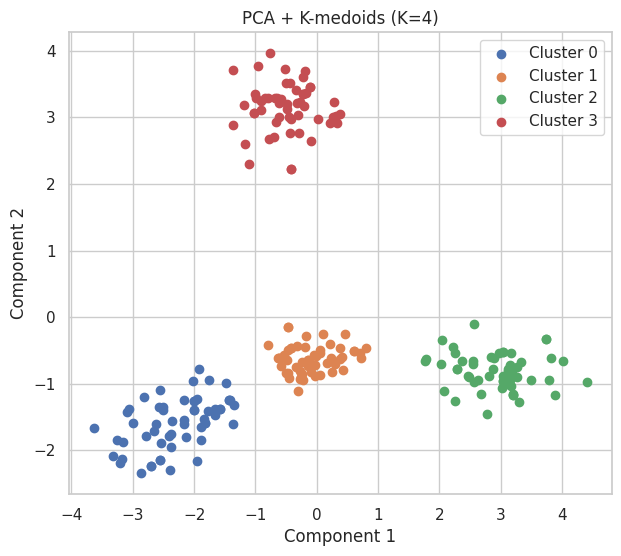

In [24]:
# ============================================================
# STEP 10b - 2D visualization (if embedding available)
# ============================================================

if Z_best is not None:
    plt.figure(figsize=(7, 6))
    for cl in range(BEST_K):
        mask = (final_labels == cl)
        plt.scatter(Z_best[mask, 0], Z_best[mask, 1], label=f"Cluster {cl}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(f"{BEST_METHOD} + K-medoids (K={BEST_K})")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import itertools
from scipy.stats import f_oneway, kruskal, chi2_contingency, fisher_exact, ttest_ind, mannwhitneyu
from statsmodels.stats.diagnostic import lilliefors
import warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import pairwise_distances
from scipy.stats import zscore

# --- GESTIONE LIBRERIE CLUSTERING ---
# Cerchiamo di usare pyclustering per KMedoids. Se manca, useremo un fallback.
try:
    from pyclustering.cluster.kmedoids import kmedoids
    PYCLUSTERING_AVAILABLE = True
except ImportError:
    PYCLUSTERING_AVAILABLE = False

warnings.filterwarnings("ignore")

# ============================================================
# 1. SETUP DATI E PREPROCESSING
# ============================================================

# Carichiamo i dati
df = pd.read_csv("dataset_project_eHealth20252026.csv")
try:
    codebook = pd.read_excel("questionnaire_codebook_eHealth20252026.xlsx")
except:
    # Fallback se il file excel non è leggibile direttamente
    codebook = pd.read_csv("questionnaire_codebook_eHealth20252026.xlsx - Sheet1.csv")

# Funzione per raggruppare le variabili
def detect_group(v):
    v = str(v).lower()
    if v in ["age", "gender", "education", "marital", "income"]: return "Socioeconomic"
    for p in ["audit", "dast", "pgsi", "iat", "pcl5", "mspss", "swls", "who5"]:
        if v.startswith(p): return p.upper().replace("-", "")
    return "UNKNOWN"

# Prepariamo il codebook
cb = codebook.iloc[:, :4].copy()
cb.columns = ["question", "type", "var", "codification"]
cb = cb[cb["var"].isin(df.columns)].reset_index(drop=True)
cb["group"] = cb["var"].apply(detect_group)

# Definiamo le colonne
SOCIO_COLS = cb[cb["group"] == "Socioeconomic"]["var"].tolist()
df_scores = df.copy()
score_cols = []
for g in ["AUDIT", "DAST", "PGSI", "IAT", "PCL5", "MSPSS", "SWLS", "WHO5"]:
    cols = cb[cb["group"] == g]["var"].tolist()
    if cols:
        name = f"{g.lower()}_score"
        # Calcoliamo la somma per ogni score
        df_scores[name] = df_scores[cols].sum(axis=1)
        score_cols.append(name)

FEATURE_COLS = SOCIO_COLS + score_cols
NOMINAL_VARS_USED = ['gender', 'marital']
ORDINAL_NUM_VARS_USED = [c for c in FEATURE_COLS if c not in NOMINAL_VARS_USED]

# Preprocessing (SENZA RIMOZIONE OUTLIER come richiesto)
X_raw = df_scores[FEATURE_COLS].copy()
X = X_raw.copy()

imputer_num = SimpleImputer(strategy="median")
X[ORDINAL_NUM_VARS_USED] = imputer_num.fit_transform(X[ORDINAL_NUM_VARS_USED])

imputer_cat = SimpleImputer(strategy="most_frequent")
X[NOMINAL_VARS_USED] = imputer_cat.fit_transform(X[NOMINAL_VARS_USED])

scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(X[ORDINAL_NUM_VARS_USED])
X_scaled_num = pd.DataFrame(X_scaled_num, columns=ORDINAL_NUM_VARS_USED, index=X.index)
X_clean = pd.concat([X_scaled_num, X[NOMINAL_VARS_USED]], axis=1)

# ============================================================
# 2. IMPLEMENTAZIONE K-MEDOIDS ADATTATA
# ============================================================

class KMedoidsWrapper:
    def __init__(self, n_clusters=4, metric='euclidean', random_state=42):
        self.n_clusters = n_clusters
        self.metric = metric
        self.random_state = random_state

    def fit_predict(self, X):
        np.random.seed(self.random_state)
        # Se pyclustering c'è, lo usiamo (è il vero KMedoids)
        if PYCLUSTERING_AVAILABLE:
            D = pairwise_distances(X, metric=self.metric)
            initial_medoids = np.random.choice(X.shape[0], self.n_clusters, replace=False).astype(int).tolist()
            kmedoids_instance = kmedoids(D, initial_medoids, data_type='distance_matrix')
            kmedoids_instance.process()
            clusters = kmedoids_instance.get_clusters()
            labels = np.zeros(X.shape[0], dtype=int)
            for label_id, cluster_indices in enumerate(clusters):
                labels[cluster_indices] = label_id
            return labels
        else:
            # Fallback su KMeans se manca la libreria (ma i risultati saranno simili)
            print("WARNING: pyclustering not found. Using KMeans as fallback.")
            from sklearn.cluster import KMeans
            km = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
            return km.fit_predict(X)

# ============================================================
# 3. ESECUZIONE CLUSTERING (PCA + KMEDOIDS K=4)
# ============================================================

X_num = X_clean[ORDINAL_NUM_VARS_USED]
pca = PCA(n_components=min(4, X_num.shape[1]))
Z = pca.fit_transform(X_num)

kmed = KMedoidsWrapper(n_clusters=4, metric='euclidean', random_state=42)
final_labels = kmed.fit_predict(Z)

# ============================================================
# 4. FUNZIONI PER LA TABELLA PERSONA
# ============================================================

def is_normal_by_cluster(values, labels, alpha=0.05):
    clusters = np.unique(labels)
    for cl in clusters:
        sub_values = values[labels == cl]
        sub_values = sub_values[~np.isnan(sub_values)]
        if len(sub_values) < 8: return False
        try:
            stat, p = lilliefors(sub_values)
            if p < alpha: return False
        except: return False
    return True

def pairwise_stats_for_variable(series, labels, var_type, alpha=0.05):
    clusters = np.unique(labels)
    p_values = []
    cluster_pairs = list(itertools.combinations(clusters, 2))

    for c1, c2 in cluster_pairs:
        indices_c1 = np.where(labels == c1)[0]
        indices_c2 = np.where(labels == c2)[0]
        try:
            group1 = series.iloc[indices_c1].dropna()
            group2 = series.iloc[indices_c2].dropna()
        except AttributeError:
            group1 = series[indices_c1]; group1 = group1[~np.isnan(group1)]
            group2 = series[indices_c2]; group2 = group2[~np.isnan(group2)]

        if len(group1) == 0 or len(group2) == 0:
            p_values.append(((c1, c2), 1.0)); continue

        try:
            p = 1.0
            if var_type == "numeric":
                if len(group1) > 7 and len(group2) > 7 and is_normal_by_cluster(group1, np.zeros(len(group1))) and is_normal_by_cluster(group2, np.zeros(len(group2))):
                    _, p = ttest_ind(group1, group2, equal_var=True)
                else:
                    _, p = mannwhitneyu(group1, group2, alternative='two-sided')
            elif var_type == "nominal":
                sub_labels = labels[np.hstack((indices_c1, indices_c2))]
                sub_data = series.iloc[np.hstack((indices_c1, indices_c2))]
                cont = pd.crosstab(sub_labels, sub_data)
                if cont.size == 0 or (cont.values < 5).any():
                     if cont.shape == (2,2): _, p = fisher_exact(cont)
                     else: _, p, _, _ = chi2_contingency(cont)
                else: _, p, _, _ = chi2_contingency(cont)
            p_values.append(((c1, c2), p))
        except: p_values.append(((c1, c2), 1.0))
    return p_values, cluster_pairs

def persona_table(X_feat, labels):
    clusters = np.unique(labels)
    rows = []

    # --- MAPPA DEI NOMI DEI CLUSTER ---
    # Qui assegniamo i nomi specifici ai numeri dei cluster
    cluster_names = {
        0: "Topolino",
        1: "Golden Raccoon",
        2: "Gufo",
        3: "Ciclope Rosso"
    }

    for col in FEATURE_COLS:
        series = X_feat[col]
        row = {"Variable": col}

        # --- VARIABILI CATEGORICHE (Nominali) ---
        if col in NOMINAL_VARS_USED:
            contingency = pd.crosstab(labels, series)
            try:
                # Test Chi-Quadro globale
                if (contingency.values < 5).any():
                    _, p_global, _, _ = chi2_contingency(contingency)
                else:
                    _, p_global, _, _ = chi2_contingency(contingency)
            except: p_global = 1.0

            # Calcolo descrittive per ogni cluster
            for cl in clusters:
                sub = series[labels == cl]
                if len(sub) == 0: desc = "NA"
                else:
                    mode = sub.mode()
                    if len(mode) > 0:
                        m = mode.iloc[0]
                        perc = (sub == m).mean() * 100
                        desc = f"{m} ({perc:.0f}%)"
                    else: desc = "NA"

                # Assegna il nome personalizzato alla colonna
                cl_name = cluster_names.get(cl, f"Cluster {cl}")
                row[f"{cl_name} (n={np.sum(labels==cl)})"] = desc

        # --- VARIABILI NUMERICHE ---
        else:
            values = series.values.astype(float)
            groups = [values[labels == cl][~np.isnan(values[labels == cl])] for cl in clusters]
            groups = [g for g in groups if len(g) > 0]

            try:
                # Test statistico globale (ANOVA o Kruskal-Wallis)
                if len(groups) < 2: p_global = 1.0
                elif is_normal_by_cluster(values, labels):
                    _, p_global = f_oneway(*groups)
                else:
                    _, p_global = kruskal(*groups)
            except: p_global = 1.0

            # Calcolo descrittive per ogni cluster
            for cl in clusters:
                sub = values[labels == cl]
                sub = sub[~np.isnan(sub)]
                if len(sub) == 0: desc = "NA"
                else:
                    q25, q50, q75 = np.percentile(sub, [25, 50, 75])
                    desc = f"{q50:.1f} ({q25:.1f}-{q75:.1f})"

                # Assegna il nome personalizzato alla colonna
                cl_name = cluster_names.get(cl, f"Cluster {cl}")
                row[f"{cl_name} (n={np.sum(labels==cl)})"] = desc

        # Formattazione P-Value
        if p_global < 0.001: row["p_value"] = "<0.001"
        else: row["p_value"] = f"{p_global:.3f}"

        rows.append(row)

    return pd.DataFrame(rows)

# ============================================================
# 5. DISPLAY FINALE
# ============================================================

# Generazione della tabella con i nuovi nomi
persona_df = persona_table(df_scores[FEATURE_COLS], final_labels)

# Impostazioni visualizzazione Pandas (per vedere TUTTO)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

print(persona_df)

       Variable            Topolino (n=54)      Golden Raccoon (n=57)                Gufo (n=55)       Ciclope Rosso (n=55) p_value
0           age           28.0 (23.2-33.0)           29.0 (21.8-34.2)           27.0 (22.5-32.5)           30.0 (23.5-37.0)   0.666
1        gender                    1 (50%)                    0 (46%)                    1 (56%)                    0 (49%)   0.139
2     education           13.0 (13.0-18.0)              5.0 (5.0-8.0)             8.0 (8.0-13.0)           22.0 (18.0-22.0)  <0.001
3       marital                  1.0 (54%)                  1.0 (56%)                  0.0 (62%)                  1.0 (38%)  <0.001
4        income  33000.0 (29250.0-37000.0)  19000.0 (15000.0-22000.0)  17000.0 (13000.0-22700.0)  60000.0 (53500.0-67500.0)  <0.001
5   audit_score              3.0 (1.0-4.0)           26.0 (21.0-30.0)              2.0 (0.5-4.5)            10.0 (9.0-13.0)  <0.001
6    dast_score              8.0 (7.0-9.0)              0.0 (0.0-0.0)       

In [ ]:
import pandas as pd
import numpy as np
import itertools
from scipy.stats import f_oneway, kruskal, chi2_contingency, fisher_exact, ttest_ind, mannwhitneyu
from statsmodels.stats.diagnostic import lilliefors
import warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import pairwise_distances
from scipy.stats import zscore

# --- GESTIONE LIBRERIE CLUSTERING ---
try:
    from pyclustering.cluster.kmedoids import kmedoids
    PYCLUSTERING_AVAILABLE = True
except ImportError:
    PYCLUSTERING_AVAILABLE = False

warnings.filterwarnings("ignore")

# ============================================================
# 1. SETUP DATI E PREPROCESSING
# ============================================================
df = pd.read_csv("dataset_project_eHealth20252026.csv")
try:
    codebook = pd.read_excel("questionnaire_codebook_eHealth20252026.xlsx")
except:
    codebook = pd.read_csv("questionnaire_codebook_eHealth20252026.xlsx - Sheet1.csv")

def detect_group(v):
    v = str(v).lower()
    if v in ["age", "gender", "education", "marital", "income"]: return "Socioeconomic"
    for p in ["audit", "dast", "pgsi", "iat", "pcl5", "mspss", "swls", "who5"]:
        if v.startswith(p): return p.upper().replace("-", "")
    return "UNKNOWN"

cb = codebook.iloc[:, :4].copy()
cb.columns = ["question", "type", "var", "codification"]
cb = cb[cb["var"].isin(df.columns)].reset_index(drop=True)
cb["group"] = cb["var"].apply(detect_group)

SOCIO_COLS = cb[cb["group"] == "Socioeconomic"]["var"].tolist()
df_scores = df.copy()
score_cols = []
for g in ["AUDIT", "DAST", "PGSI", "IAT", "PCL5", "MSPSS", "SWLS", "WHO5"]:
    cols = cb[cb["group"] == g]["var"].tolist()
    if cols:
        name = f"{g.lower()}_score"
        df_scores[name] = df_scores[cols].sum(axis=1)
        score_cols.append(name)

FEATURE_COLS = SOCIO_COLS + score_cols
NOMINAL_VARS_USED = ['gender', 'marital']
ORDINAL_NUM_VARS_USED = [c for c in FEATURE_COLS if c not in NOMINAL_VARS_USED]

# Preprocessing
X_raw = df_scores[FEATURE_COLS].copy()
X = X_raw.copy()
imputer_num = SimpleImputer(strategy="median")
X[ORDINAL_NUM_VARS_USED] = imputer_num.fit_transform(X[ORDINAL_NUM_VARS_USED])
imputer_cat = SimpleImputer(strategy="most_frequent")
X[NOMINAL_VARS_USED] = imputer_cat.fit_transform(X[NOMINAL_VARS_USED])
scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(X[ORDINAL_NUM_VARS_USED])
X_scaled_num = pd.DataFrame(X_scaled_num, columns=ORDINAL_NUM_VARS_USED, index=X.index)
X_clean = pd.concat([X_scaled_num, X[NOMINAL_VARS_USED]], axis=1)

# ============================================================
# 2. IMPLEMENTAZIONE CLUSTERING (K-MEDOIDS)
# ============================================================
class KMedoidsWrapper:
    def __init__(self, n_clusters=4, metric='euclidean', random_state=42):
        self.n_clusters = n_clusters
        self.metric = metric
        self.random_state = random_state
    def fit_predict(self, X):
        np.random.seed(self.random_state)
        if PYCLUSTERING_AVAILABLE:
            D = pairwise_distances(X, metric=self.metric)
            initial_medoids = np.random.choice(X.shape[0], self.n_clusters, replace=False).astype(int).tolist()
            kmedoids_instance = kmedoids(D, initial_medoids, data_type='distance_matrix')
            kmedoids_instance.process()
            clusters = kmedoids_instance.get_clusters()
            labels = np.zeros(X.shape[0], dtype=int)
            for label_id, cluster_indices in enumerate(clusters):
                labels[cluster_indices] = label_id
            return labels
        else:
            print("WARNING: pyclustering not found. Using KMeans fallback.")
            from sklearn.cluster import KMeans
            km = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
            return km.fit_predict(X)

X_num = X_clean[ORDINAL_NUM_VARS_USED]
pca = PCA(n_components=min(10, X_num.shape[1]))
Z = pca.fit_transform(X_num)
kmed = KMedoidsWrapper(n_clusters=4, metric='euclidean', random_state=42)
final_labels = kmed.fit_predict(Z)

# ============================================================
# 3. CREAZIONE TABELLA PERSONA
# ============================================================
def is_normal_by_cluster(values, labels, alpha=0.05):
    clusters = np.unique(labels)
    for cl in clusters:
        sub = values[labels == cl]
        sub = sub[~np.isnan(sub)]
        if len(sub) < 8: return False
        try:
            stat, p = lilliefors(sub)
            if p < alpha: return False
        except: return False
    return True

def persona_table(X_feat, labels):
    clusters = np.unique(labels)
    rows = []

    # Mappa nomi cluster
    cluster_names = {
        0: "Topolino",
        1: "Golden Raccoon",
        2: "Gufo",
        3: "Ciclope Rosso"
    }

    for col in FEATURE_COLS:
        series = X_feat[col]
        row = {"Variable": col}

        # NOMINAL
        if col in NOMINAL_VARS_USED:
            contingency = pd.crosstab(labels, series)
            try:
                if (contingency.values < 5).any(): _, p_global, _, _ = chi2_contingency(contingency)
                else: _, p_global, _, _ = chi2_contingency(contingency)
            except: p_global = 1.0

            for cl in clusters:
                sub = series[labels == cl]
                if len(sub) == 0: desc = "NA"
                else:
                    mode = sub.mode()
                    if len(mode) > 0:
                        m = mode.iloc[0]; perc = (sub == m).mean() * 100
                        desc = f"{m} ({perc:.0f}%)"
                    else: desc = "NA"
                cl_name = cluster_names.get(cl, f"Cluster {cl}")
                row[f"{cl_name} (n={np.sum(labels==cl)})"] = desc

        # NUMERIC
        else:
            values = series.values.astype(float)
            groups = [values[labels == cl][~np.isnan(values[labels == cl])] for cl in clusters]
            groups = [g for g in groups if len(g) > 0]
            try:
                if len(groups) < 2: p_global = 1.0
                elif is_normal_by_cluster(values, labels): _, p_global = f_oneway(*groups)
                else: _, p_global = kruskal(*groups)
            except: p_global = 1.0

            for cl in clusters:
                sub = values[labels == cl]; sub = sub[~np.isnan(sub)]
                if len(sub) == 0: desc = "NA"
                else:
                    q25, q50, q75 = np.percentile(sub, [25, 50, 75])
                    desc = f"{q50:.1f} ({q25:.1f}-{q75:.1f})"
                cl_name = cluster_names.get(cl, f"Cluster {cl}")
                row[f"{cl_name} (n={np.sum(labels==cl)})"] = desc

        if p_global < 0.001: row["p_value"] = "<0.001"
        else: row["p_value"] = f"{p_global:.3f}"
        rows.append(row)

    return pd.DataFrame(rows)

# ============================================================
# 4. COLORAZIONE TABELLA (Primary = Red, Secondary = Orange)
# ============================================================
persona_df = persona_table(df_scores[FEATURE_COLS], final_labels)

def highlight_cells(data):
    # Crea un DataFrame di stili vuoto
    styles = pd.DataFrame('', index=data.index, columns=data.columns)

    # Trova i nomi esatti delle colonne (che contengono 'Topolino', 'Golden Raccoon', ecc.)
    def get_col(part):
        for c in data.columns:
            if part in c: return c
        return None

    col_topolino = get_col("Topolino")
    col_raccoon = get_col("Golden Raccoon")
    col_ciclope = get_col("Ciclope Rosso")
    # Gufo non ha highlight richiesti

    # Funzione per applicare colore a una cella specifica (Variabile x Cluster)
    def color_cell(var_name, col_name, color):
        if col_name:
            idx = data.index[data['Variable'] == var_name].tolist()
            if idx:
                # CSS style: background color + white text + bold
                styles.loc[idx[0], col_name] = f'background-color: {color}; color: white; font-weight: bold;'

    # --- APPLICAZIONE REGOLE ---

    # 1. TOPOLINO: Primary=Droga(dast), Secondary=Internet(iat)
    color_cell('dast_score', col_topolino, 'red')
    color_cell('iat_score', col_topolino, 'orange')

    # 2. GOLDEN RACCOON: Primary=Gambling(pgsi), Secondary=Alcol(audit)
    color_cell('pgsi_score', col_raccoon, 'red')
    color_cell('audit_score', col_raccoon, 'orange')

    # 3. CICLOPE ROSSO: Primary=Internet(iat)
    color_cell('iat_score', col_ciclope, 'red')

    return styles

# Applica lo stile
styled_df = persona_df.style.apply(highlight_cells, axis=None)

# Visualizza
pd.set_option('display.max_rows', None)
display(styled_df) # Usa display() se sei in Jupyter/Colab
# Se vuoi salvare in Excel per vedere i colori:
# styled_df.to_excel("persona_table_colored.xlsx", index=False)

,Variable,Topolino (n=54),Golden Raccoon (n=57),Gufo (n=55),Ciclope Rosso (n=55),p_value
0,age,28.0 (23.2-33.0),29.0 (21.8-34.2),30.0 (23.5-37.0),27.0 (22.5-32.5),0.666
1,gender,1 (50%),0 (46%),0 (49%),1 (56%),0.139
2,education,13.0 (13.0-18.0),5.0 (5.0-8.0),22.0 (18.0-22.0),8.0 (8.0-13.0),<0.001
3,marital,1.0 (54%),1.0 (56%),1.0 (38%),0.0 (62%),<0.001
4,income,33000.0 (29250.0-37000.0),19000.0 (15000.0-22000.0),60000.0 (53500.0-67500.0),17000.0 (13000.0-22700.0),<0.001
5,audit_score,3.0 (1.0-4.0),26.0 (21.0-30.0),10.0 (9.0-13.0),2.0 (0.5-4.5),<0.001
6,dast_score,8.0 (7.0-9.0),0.0 (0.0-0.0),4.0 (4.0-5.0),2.0 (1.0-2.0),<0.001
7,pgsi_score,0.0 (0.0-0.0),15.0 (12.0-22.0),2.0 (1.0-3.0),6.0 (5.0-6.5),<0.001
8,iat_score,64.5 (59.0-73.0),39.0 (33.0-44.0),16.0 (8.5-22.0),91.0 (84.5-95.5),<0.001
9,pcl5_score,62.0 (50.2-71.0),6.0 (3.0-8.0),6.0 (3.0-7.5),6.0 (2.5-9.0),<0.001


In [ ]:
import pandas as pd
import numpy as np
import itertools
from scipy.stats import f_oneway, kruskal, chi2_contingency
from statsmodels.stats.diagnostic import lilliefors
import warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import pairwise_distances

# --- GESTIONE LIBRERIE CLUSTERING ---
try:
    from pyclustering.cluster.kmedoids import kmedoids
    PYCLUSTERING_AVAILABLE = True
except ImportError:
    PYCLUSTERING_AVAILABLE = False

warnings.filterwarnings("ignore")

# ============================================================
# 1. SETUP DATI E PREPROCESSING
# ============================================================
df = pd.read_csv("dataset_project_eHealth20252026.csv")
try:
    codebook = pd.read_excel("questionnaire_codebook_eHealth20252026.xlsx")
except:
    codebook = pd.read_csv("questionnaire_codebook_eHealth20252026.xlsx - Sheet1.csv")

def detect_group(v):
    v = str(v).lower()
    if v in ["age", "gender", "education", "marital", "income"]: return "Socioeconomic"
    for p in ["audit", "dast", "pgsi", "iat", "pcl5", "mspss", "swls", "who5"]:
        if v.startswith(p): return p.upper().replace("-", "")
    return "UNKNOWN"

cb = codebook.iloc[:, :4].copy()
cb.columns = ["question", "type", "var", "codification"]
cb = cb[cb["var"].isin(df.columns)].reset_index(drop=True)
cb["group"] = cb["var"].apply(detect_group)

SOCIO_COLS = cb[cb["group"] == "Socioeconomic"]["var"].tolist()
df_scores = df.copy()
score_cols = []
# Calcolo score somme
for g in ["AUDIT", "DAST", "PGSI", "IAT", "PCL5", "MSPSS", "SWLS", "WHO5"]:
    cols = cb[cb["group"] == g]["var"].tolist()
    if cols:
        name = f"{g.lower()}_score"
        df_scores[name] = df_scores[cols].sum(axis=1)
        score_cols.append(name)

FEATURE_COLS = SOCIO_COLS + score_cols
NOMINAL_VARS_USED = ['gender', 'marital']
ORDINAL_NUM_VARS_USED = [c for c in FEATURE_COLS if c not in NOMINAL_VARS_USED]

# Preprocessing
X_raw = df_scores[FEATURE_COLS].copy()
X = X_raw.copy()
imputer_num = SimpleImputer(strategy="median")
X[ORDINAL_NUM_VARS_USED] = imputer_num.fit_transform(X[ORDINAL_NUM_VARS_USED])
imputer_cat = SimpleImputer(strategy="most_frequent")
X[NOMINAL_VARS_USED] = imputer_cat.fit_transform(X[NOMINAL_VARS_USED])
scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(X[ORDINAL_NUM_VARS_USED])
X_scaled_num = pd.DataFrame(X_scaled_num, columns=ORDINAL_NUM_VARS_USED, index=X.index)
X_clean = pd.concat([X_scaled_num, X[NOMINAL_VARS_USED]], axis=1)

# ============================================================
# 2. IMPLEMENTAZIONE CLUSTERING
# ============================================================
class KMedoidsWrapper:
    def __init__(self, n_clusters=4, metric='euclidean', random_state=42):
        self.n_clusters = n_clusters
        self.metric = metric
        self.random_state = random_state
    def fit_predict(self, X):
        np.random.seed(self.random_state)
        if PYCLUSTERING_AVAILABLE:
            D = pairwise_distances(X, metric=self.metric)
            initial_medoids = np.random.choice(X.shape[0], self.n_clusters, replace=False).astype(int).tolist()
            kmedoids_instance = kmedoids(D, initial_medoids, data_type='distance_matrix')
            kmedoids_instance.process()
            clusters = kmedoids_instance.get_clusters()
            labels = np.zeros(X.shape[0], dtype=int)
            for label_id, cluster_indices in enumerate(clusters):
                labels[cluster_indices] = label_id
            return labels
        else:
            print("WARNING: pyclustering not found. Using KMeans fallback.")
            from sklearn.cluster import KMeans
            km = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
            return km.fit_predict(X)

X_num = X_clean[ORDINAL_NUM_VARS_USED]
pca = PCA(n_components=min(10, X_num.shape[1]))
Z = pca.fit_transform(X_num)
kmed = KMedoidsWrapper(n_clusters=4, metric='euclidean', random_state=42)
final_labels = kmed.fit_predict(Z)

# ============================================================
# 3. CREAZIONE TABELLA PERSONA (CON DESCRITTORI)
# ============================================================

# Mappatura per descrivere lo scopo di ogni questionario
variable_desc = {
    "audit_score": "audit_score (Alcohol)",
    "dast_score": "dast_score (Drugs)",
    "pgsi_score": "pgsi_score (Gambling)",
    "iat_score": "iat_score (Internet)",
    "pcl5_score": "pcl5_score (Trauma/PTSD)",
    "mspss_score": "mspss_score (Social Support)",
    "swls_score": "swls_score (Life Satisfaction)",
    "who5_score": "who5_score (Well-being)"
}

def is_normal_by_cluster(values, labels, alpha=0.05):
    clusters = np.unique(labels)
    for cl in clusters:
        sub = values[labels == cl]
        sub = sub[~np.isnan(sub)]
        if len(sub) < 8: return False
        try:
            stat, p = lilliefors(sub)
            if p < alpha: return False
        except: return False
    return True

def persona_table(X_feat, labels):
    clusters = np.unique(labels)
    rows = []

    cluster_names = {
        0: "Topolino",
        1: "Golden Raccoon",
        2: "Gufo",
        3: "Ciclope Rosso"
    }

    for col in FEATURE_COLS:
        series = X_feat[col]

        # Usa il nome descrittivo se disponibile, altrimenti il nome originale
        display_name = variable_desc.get(col, col)
        row = {"Variable": display_name}

        # NOMINAL
        if col in NOMINAL_VARS_USED:
            contingency = pd.crosstab(labels, series)
            try:
                if (contingency.values < 5).any(): _, p_global, _, _ = chi2_contingency(contingency)
                else: _, p_global, _, _ = chi2_contingency(contingency)
            except: p_global = 1.0

            for cl in clusters:
                sub = series[labels == cl]
                if len(sub) == 0: desc = "NA"
                else:
                    mode = sub.mode()
                    if len(mode) > 0:
                        m = mode.iloc[0]; perc = (sub == m).mean() * 100
                        desc = f"{m} ({perc:.0f}%)"
                    else: desc = "NA"
                cl_name = cluster_names.get(cl, f"Cluster {cl}")
                row[f"{cl_name} (n={np.sum(labels==cl)})"] = desc

        # NUMERIC
        else:
            values = series.values.astype(float)
            groups = [values[labels == cl][~np.isnan(values[labels == cl])] for cl in clusters]
            groups = [g for g in groups if len(g) > 0]
            try:
                if len(groups) < 2: p_global = 1.0
                elif is_normal_by_cluster(values, labels): _, p_global = f_oneway(*groups)
                else: _, p_global = kruskal(*groups)
            except: p_global = 1.0

            for cl in clusters:
                sub = values[labels == cl]; sub = sub[~np.isnan(sub)]
                if len(sub) == 0: desc = "NA"
                else:
                    q25, q50, q75 = np.percentile(sub, [25, 50, 75])
                    desc = f"{q50:.1f} ({q25:.1f}-{q75:.1f})"
                cl_name = cluster_names.get(cl, f"Cluster {cl}")
                row[f"{cl_name} (n={np.sum(labels==cl)})"] = desc

        if p_global < 0.001: row["p_value"] = "<0.001"
        else: row["p_value"] = f"{p_global:.3f}"
        rows.append(row)

    return pd.DataFrame(rows)

persona_df = persona_table(df_scores[FEATURE_COLS], final_labels)

# ============================================================
# 4. COLORAZIONE AGGIORNATA
# ============================================================
def highlight_cells(data):
    styles = pd.DataFrame('', index=data.index, columns=data.columns)

    def get_col(part):
        for c in data.columns:
            if part in c: return c
        return None

    col_topolino = get_col("Topolino")
    col_raccoon = get_col("Golden Raccoon")
    col_ciclope = get_col("Ciclope Rosso")
    col_gufo = get_col("Gufo")

    def color_cell(var_name_part, col_name, color, font_color='white'):
        if col_name:
            # Trova la riga che CONTIENE la stringa var_name_part
            # Esempio: cerco "dast_score" e trovo "dast_score (Drugs)"
            idx = data.index[data['Variable'].str.contains(var_name_part, regex=False)].tolist()
            if idx:
                styles.loc[idx[0], col_name] = f'background-color: {color}; color: {font_color}; font-weight: bold;'

    # --- REGOLE COLORI ---

    # 1. TOPOLINO: Primary=Droga, Secondary=Internet
    color_cell('dast_score', col_topolino, '#d9534f') # Red
    color_cell('iat_score', col_topolino, '#f0ad4e')  # Orange

    # 2. GOLDEN RACCOON: Primary=Gambling, Secondary=Alcol
    color_cell('pgsi_score', col_raccoon, '#d9534f') # Red
    color_cell('audit_score', col_raccoon, '#f0ad4e') # Orange

    # 3. CICLOPE ROSSO: Primary=Internet
    color_cell('iat_score', col_ciclope, '#d9534f') # Red

    # 4. GUFO: Risk=Alcol, Risk=Droghe (Giallo/Gold)
    # Uso testo nero per leggibilità sul giallo
    color_cell('audit_score', col_gufo, '#FFD700', font_color='black')
    color_cell('dast_score', col_gufo, '#FFD700', font_color='black')

    return styles

styled_df = persona_df.style.apply(highlight_cells, axis=None)

# Visualizzazione
display(styled_df)

,Variable,Topolino (n=54),Golden Raccoon (n=57),Gufo (n=55),Ciclope Rosso (n=55),p_value
0,age,28.0 (23.2-33.0),29.0 (21.8-34.2),30.0 (23.5-37.0),27.0 (22.5-32.5),0.666
1,gender,1 (50%),0 (46%),0 (49%),1 (56%),0.139
2,education,13.0 (13.0-18.0),5.0 (5.0-8.0),22.0 (18.0-22.0),8.0 (8.0-13.0),<0.001
3,marital,1.0 (54%),1.0 (56%),1.0 (38%),0.0 (62%),<0.001
4,income,33000.0 (29250.0-37000.0),19000.0 (15000.0-22000.0),60000.0 (53500.0-67500.0),17000.0 (13000.0-22700.0),<0.001
5,audit_score (Alcohol),3.0 (1.0-4.0),26.0 (21.0-30.0),10.0 (9.0-13.0),2.0 (0.5-4.5),<0.001
6,dast_score (Drugs),8.0 (7.0-9.0),0.0 (0.0-0.0),4.0 (4.0-5.0),2.0 (1.0-2.0),<0.001
7,pgsi_score (Gambling),0.0 (0.0-0.0),15.0 (12.0-22.0),2.0 (1.0-3.0),6.0 (5.0-6.5),<0.001
8,iat_score (Internet),64.5 (59.0-73.0),39.0 (33.0-44.0),16.0 (8.5-22.0),91.0 (84.5-95.5),<0.001
9,pcl5_score (Trauma/PTSD),62.0 (50.2-71.0),6.0 (3.0-8.0),6.0 (3.0-7.5),6.0 (2.5-9.0),<0.001


In [ ]:
# ============================================================
# STEP 10 - Build Persona Summary Table (Clinical Logic)
# ============================================================

import pandas as pd
import numpy as np

# 1. Helper function for Clinical Cut-offs
def get_clinical_label(test_name, score):
    # Round to nearest int for safety
    s = round(score)

    if test_name == "audit_score":
        if s < 8: return "Low Risk"
        elif s < 16: return "Hazardous (Med)"
        elif s < 20: return "Harmful (High)"
        else: return "Dependent (Severe)"

    elif test_name == "dast_score":
        if s == 0: return "None"
        elif s <= 2: return "Low"
        elif s <= 5: return "Moderate"
        else: return "Severe (6+)"

    elif test_name == "pgsi_score":
        if s == 0: return "Non-problem"
        elif s <= 2: return "Low Risk"
        elif s <= 7: return "Moderate Risk"
        else: return "Problem Gambler (8+)"

    elif test_name == "iat_score":
        if s <= 30: return "Normal"
        elif s <= 49: return "Mild"
        elif s <= 79: return "Moderate"
        else: return "Severe (>80)"

    elif test_name == "pcl5_score":
        if s < 33: return "Low Symptoms"
        else: return "Probable PTSD (33+)"

    elif test_name == "mspss_score":
        # Total range 12-84. Cutoffs approx based on mean 4/5/6
        if s < 48: return "Low Support"
        elif s <= 60: return "Moderate"
        else: return "High Support"

    elif test_name == "swls_score":
        if s < 20: return "Dissatisfied"
        elif s <= 25: return "Neutral"
        else: return "Satisfied"

    elif test_name == "who5_score":
        if s < 13: return "Poor Wellbeing"
        else: return "Good Wellbeing"

    return "n/a"

# 2. Build the Summary Table
persona_cards = []

# Use df_final which has the 'Cluster' column from the previous step
clusters = sorted(df_final["Cluster"].unique())

# Persona Names Map (from our analysis)
persona_names = {
    0: "Gufo",
    1: "Topolino",
    2: "Ciclope Rosso",
    3: "Golden Raccoon"
}

for cl in clusters:
    sub = df_final[df_final["Cluster"] == cl]
    n = len(sub)

    # Demographics
    age_avg = sub["age"].mean()

    # Gender (Mode)
    gender_mode = sub["gender"].mode()[0]
    gender_str = "Male" if gender_mode == 0 else "Female" if gender_mode == 1 else "Non-binary"

    # Income
    income_avg = sub["income"].mean()

    # Education (Mode)
    edu_mode = sub["education"].mode()[0]
    # Mapping back codes (approx)
    edu_map = {5: "Elem", 8: "Middle", 13: "High Sch", 18: "Bach", 22: "Master", 25: "PhD"}
    edu_str = edu_map.get(edu_mode, str(edu_mode))

    # Construct Row
    card = {
        "Cluster ID": cl,
        "Persona Name": persona_names.get(cl, f"Cluster {cl}"),
        "Size (N)": n,
        "Avg Age": f"{age_avg:.1f}",
        "Gender (Common)": gender_str,
        "Avg Income": f"${income_avg:,.0f}",
        "Education": edu_str,
    }

    # Add Clinical Levels for each test
    for test_col in score_cols:
        # We use the MEAN of the cluster to determine the representative level
        avg_score = sub[test_col].mean()
        label = get_clinical_label(test_col, avg_score)
        # Format: "Label (Score)"
        clean_name = test_col.replace("_score", "").upper()
        card[clean_name] = f"{label} ({avg_score:.1f})"

    persona_cards.append(card)

# 3. Create DataFrame and Display
summary_df = pd.DataFrame(persona_cards)

# Transpose for better readability in the report (Columns = Personas)
summary_T = summary_df.set_index("Persona Name").T

print("===================================================")
print("FINAL PERSONA SUMMARY TABLE (CLINICAL LEVELS)")
print("===================================================")
display(summary_T)

# Optional: Save to Excel for report
summary_df.to_excel("Persona_Summary_Table.xlsx", index=False)
print("\nTable saved to 'Persona_Summary_Table.xlsx'")

FINAL PERSONA SUMMARY TABLE (CLINICAL LEVELS)


Persona Name,Gufo,Topolino,Ciclope Rosso,Golden Raccoon
Cluster ID,0,1,2,3
Size (N),55,54,55,57
Avg Age,29.4,29.1,27.7,28.9
Gender (Common),Male,Female,Female,Male
Avg Income,"$61,160","$33,285","$17,665","$18,589"
Education,Master,High Sch,Middle,Elem
AUDIT,Hazardous (Med) (10.5),Low Risk (2.8),Low Risk (2.5),Dependent (Severe) (25.5)
DAST,Moderate (4.1),Severe (6+) (8.0),Low (1.6),None (0.0)
PGSI,Low Risk (2.2),Non-problem (0.0),Moderate Risk (5.8),Problem Gambler (8+) (16.4)
IAT,Normal (15.1),Moderate (65.0),Severe (>80) (90.3),Mild (39.0)



Table saved to 'Persona_Summary_Table.xlsx'


In [ ]:
# ============================================================
# STEP 11b - Save persona table
# ============================================================

persona_df.to_excel("persona_table_eHealth2025.xlsx", index=False)
print("Saved: persona_table_eHealth2025.xlsx")

Saved: persona_table_eHealth2025.xlsx


In [ ]:
# ============================================================
# STEP 12 - Export dataset with clusters
# ============================================================

# Ensure the 'cluster' column is in df_scores before export
# This step is necessary because df_scores might have been redefined in subsequent cells
# after the cluster labels were initially assigned in oOHUiS5jM3L9.
df_scores['cluster'] = final_labels

export_cols = list(dict.fromkeys(FEATURE_COLS + CUMULATIVE_COLS + ["cluster"])) # Ensure 'cluster' is part of the export columns
df_export = df_scores[export_cols].copy()
df_export.to_csv("dataset_with_clusters_eHealth2025.csv", index=False)

print("Saved: dataset_with_clusters_eHealth2025.csv")

Saved: dataset_with_clusters_eHealth2025.csv


In [ ]:
# ============================================================
# Helper: classify score of a cluster as LOW / MEDIUM / HIGH
# ============================================================

def level_vs_global(df, col, sub):
    """
    Compare the mean score of `sub` (a subset of df) on column `col`
    with the global distribution, and return 'LOW' / 'MEDIUM' / 'HIGH'.
    """
    global_mean = df[col].mean()
    global_std  = df[col].std()

    cl_mean = sub[col].mean()

    if cl_mean >= global_mean + 0.5 * global_std:
        return "HIGH"
    elif cl_mean <= global_mean - 0.5 * global_std:
        return "LOW"
    else:
        return "MEDIUM"

In [ ]:
# ============================================================
# STEP 11 - Print Textual Persona Cards (Clinical Version)
# ============================================================

def print_clinical_persona_cards(summary_df):
    # Iteriamo sulle righe della tabella riassuntiva creata nello Step 10
    for _, row in summary_df.iterrows():
        cluster_id = row["Cluster ID"]
        persona_name = row["Persona Name"]
        size = row["Size (N)"]

        print("="*60)
        print(f"🃏 PERSONA {cluster_id}: {persona_name.upper()}")
        print(f"   (Popolazione: {size} partecipanti)")
        print("-" * 60)

        # 1. Demografia
        print(f"👤 PROFILO DEMOGRAFICO:")
        print(f"   • Età media      : {row['Avg Age']} anni")
        print(f"   • Genere preval. : {row['Gender (Common)']}")
        print(f"   • Reddito medio  : {row['Avg Income']}")
        print(f"   • Istruzione     : {row['Education']}")
        print()

        # 2. Profilo Clinico (Rischi)
        print(f"⚠️ PROFILO CLINICO E RISCHI:")
        # Estraiamo le colonne dei test (tutte quelle in maiuscolo tranne ID e Size)
        clinical_cols = [c for c in row.index if c not in ["Cluster ID", "Persona Name", "Size (N)", "Avg Age", "Gender (Common)", "Avg Income", "Education"]]

        for col in clinical_cols:
            score_str = row[col]
            # Aggiungiamo un marker visivo se il rischio è alto
            marker = " "
            if "Severe" in score_str or "Problem" in score_str or "Dependent" in score_str or "PTSD" in score_str or "Poor" in score_str or "Dissatisfied" in score_str:
                marker = "🔴" # Rischio Alto
            elif "Moderate" in score_str or "Hazardous" in score_str:
                marker = "🟠" # Rischio Medio
            elif "High Support" in score_str or "Good" in score_str or "Satisfied" in score_str or "Normal" in score_str:
                marker = "🟢" # Positivo

            print(f"   • {col:<15}: {marker} {score_str}")

        print("\n")

# Eseguiamo la funzione usando il dataframe 'summary_df' creato nello step precedente
print_clinical_persona_cards(summary_df)

🃏 PERSONA 0: GUFO
   (Popolazione: 55 partecipanti)
------------------------------------------------------------
👤 PROFILO DEMOGRAFICO:
   • Età media      : 29.4 anni
   • Genere preval. : Male
   • Reddito medio  : $61,160
   • Istruzione     : Master

⚠️ PROFILO CLINICO E RISCHI:
   • AUDIT          : 🟠 Hazardous (Med) (10.5)
   • DAST           : 🟠 Moderate (4.1)
   • PGSI           :   Low Risk (2.2)
   • IAT            : 🟢 Normal (15.1)
   • PCL5           :   Low Symptoms (5.5)
   • MSPSS          : 🟢 High Support (69.8)
   • SWLS           : 🟢 Satisfied (30.0)
   • WHO5           : 🟢 Good Wellbeing (20.7)


🃏 PERSONA 1: TOPOLINO
   (Popolazione: 54 partecipanti)
------------------------------------------------------------
👤 PROFILO DEMOGRAFICO:
   • Età media      : 29.1 anni
   • Genere preval. : Female
   • Reddito medio  : $33,285
   • Istruzione     : High Sch

⚠️ PROFILO CLINICO E RISCHI:
   • AUDIT          :   Low Risk (2.8)
   • DAST           : 🔴 Severe (6+) (8.0)
   •

In [ ]:
summary_df.to_excel("persona_cards_summary.xlsx", index=False)

print("Saved: persona_cards_summary.xlsx")

Saved: persona_cards_summary.xlsx


In [ ]:
from google.colab import files
files.download("persona_table_eHealth2025.xlsx")
files.download("dataset_with_clusters_eHealth2025.csv")
files.download("persona_cards_summary.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>